# Worm-species manuscript figures and LaTeX tables

This notebook reads the saved artefacts inside every `run_dir`, including:

- `confusion_matrix_best_{task}.csv`;
- `classification_report_best_{task}.csv`;
- `label_to_index_by_task.json`;
- `test_metrics_best.json`;
- `run_summary.json`, `split_summary.json`, and `config.json` when needed.

It creates:

1. one combined baseline-performance figure;
2. one combined visual-ablation figure containing colour, patch shuffling, Gaussian blur, and resolution loss;
3. one detailed target-recall figure for the structured holdouts;
4. raw and row-normalised confusion matrices for selected runs and tasks;
5. manuscript-ready LaTeX tables from summaries and classification reports.

The notebook should be run on Genome/GHPC, where the absolute `run_dir` paths are available.

In [1]:
from io import StringIO
from pathlib import Path
import json
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
})

OUTPUT_DIR = Path("worm_species_manuscript_outputs")
FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
CM_DIR = OUTPUT_DIR / "confusion_matrices"
REPORT_DIR = TABLE_DIR / "classification_reports"
for directory in (FIGURE_DIR, TABLE_DIR, CM_DIR, REPORT_DIR):
    directory.mkdir(parents=True, exist_ok=True)

MODEL_ORDER = ["resnet50", "convnext_base", "vit_b_16"]
MODEL_LABELS = {
    "resnet50": "ResNet-50",
    "convnext_base": "ConvNeXt-Base",
    "vit_b_16": "ViT-B/16",
}
TASK_ORDER = ["genus", "species", "age"]
TASK_LABELS = {
    "genus": "Genus",
    "species": "Species",
    "age": "Developmental stage",
}
METRIC_COLUMNS = {
    "test_mean_macro_f1": "Mean",
    "test_genus_macro_f1": "Genus",
    "test_species_macro_f1": "Species",
    "test_age_macro_f1": "Developmental stage",
}

# Change these only when using newer summary files.
RESULTS_CSV = Path("results_snapshot.csv")
HOLDOUT_TARGET_CSV = Path("holdout_target_metrics.csv")

# Best checkpoint is the manuscript default. Fallbacks are handled automatically.
CHECKPOINT = "best"

# Confusion-matrix plan.
GENERATE_BASELINE_CMS = True
GENERATE_HOLDOUT_CMS = True
GENERATE_VISUAL_CMS = False
VISUAL_CM_CONDITIONS = [
    "colour_000pct",
    "patch_shuffle_16x16",
    "gaussian_blur_100pct",
    "resolution_loss_100pct",
]
VISUAL_CM_MODELS = ["convnext_base"]


def save_figure(fig, stem, directory=FIGURE_DIR):
    for suffix in ("svg", "pdf", "png"):
        fig.savefig(directory / f"{stem}.{suffix}")
    print(f"Saved {stem} as SVG, PDF, and PNG")


def latex_escape(value):
    text = str(value)
    replacements = {
        "\\": r"\textbackslash{}",
        "&": r"\&", "%": r"\%", "$": r"\$", "#": r"\#",
        "_": r"\_", "{": r"\{", "}": r"\}",
        "~": r"\textasciitilde{}", "^": r"\textasciicircum{}",
    }
    for old, new in replacements.items():
        text = text.replace(old, new)
    return text


def safe_stem(text):
    return re.sub(r"[^A-Za-z0-9._-]+", "_", str(text)).strip("_")

In [2]:
EMBEDDED_RESULTS = "stage,model,seed,total_parameters,trainable_parameters,pretrained,learning_rate,batch_size,selection_metric,loss_recipe,genus_weight,species_weight,age_weight,condition,transform,strength,percent,grid_size,colour_retention,holdout,holdout_question,best_epoch,best_val_score,test_mean_macro_f1,test_genus_macro_f1,test_species_macro_f1,test_age_macro_f1,run_dir\nbaseline,resnet50,40,23534669,23534669,True,0.0003,256,mean_macro_f1,genus-2_species-1_age-0.5,2.0,1.0,0.5,original,original,0.0,,,,,,45,0.8965180208251838,0.8095261857213719,0.9591438120595072,0.6829575414501493,0.7864772036544592,/faststorage/project/worm-species/source/paper_result/runs/baseline/run_000_resnet50_original_seed_40_20260729201916/lr_0.0003_hloss_False_f2813dc3_train_original\nbaseline,resnet50,41,23534669,23534669,True,0.0003,256,mean_macro_f1,genus-2_species-1_age-0.5,2.0,1.0,0.5,original,original,0.0,,,,,,65,0.8822427940260452,0.8438578274343635,0.9672210504016814,0.7511763504050206,0.8131760814963884,/faststorage/project/worm-species/source/paper_result/runs/baseline/run_001_resnet50_original_seed_41_20260729201916/lr_0.0003_hloss_False_92eedfaf_train_original\nbaseline,resnet50,42,23534669,23534669,True,0.0003,256,mean_macro_f1,genus-2_species-1_age-0.5,2.0,1.0,0.5,original,original,0.0,,,,,,90,0.8968490581154936,0.8478273802733535,0.9729793555498519,0.7534972847001933,0.8170055005700151,/faststorage/project/worm-species/source/paper_result/runs/baseline/run_002_resnet50_original_seed_42_20260729201916/lr_0.0003_hloss_False_4e0742eb_train_original\nbaseline,convnext_base,40,87579789,87579789,True,0.0003,256,mean_macro_f1,genus-2_species-1_age-0.5,2.0,1.0,0.5,original,original,0.0,,,,,,90,0.9128012976315314,0.8566368172298394,0.9851689805191866,0.7543708528060397,0.8303706183642919,/faststorage/project/worm-species/source/paper_result/runs/baseline/run_003_convnext_base_original_seed_40_20260729201916/lr_0.0003_hloss_False_8b056322_train_original\nbaseline,convnext_base,41,87579789,87579789,True,0.0003,256,mean_macro_f1,genus-2_species-1_age-0.5,2.0,1.0,0.5,original,original,0.0,,,,,,15,0.9001554697300239,0.8617654189041102,0.9815347230855878,0.8052225584626517,0.798538975164091,/faststorage/project/worm-species/source/paper_result/runs/baseline/run_004_convnext_base_original_seed_41_20260729201916/lr_0.0003_hloss_False_0a5fd394_train_original\nbaseline,convnext_base,42,87579789,87579789,True,0.0003,256,mean_macro_f1,genus-2_species-1_age-0.5,2.0,1.0,0.5,original,original,0.0,,,,,,25,0.9120570047962037,0.8687030442409517,0.9737936394485761,0.7973219691956259,0.834993524078653,/faststorage/project/worm-species/source/paper_result/runs/baseline/run_005_convnext_base_original_seed_42_20260729201916/lr_0.0003_hloss_False_4f21266e_train_original\nbaseline,vit_b_16,40,85808653,85808653,True,0.0003,256,mean_macro_f1,genus-2_species-1_age-0.5,2.0,1.0,0.5,original,original,0.0,,,,,,95,0.8588441963280312,0.8135047685128249,0.9514897715981876,0.7088785823591448,0.7801459515811422,/faststorage/project/worm-species/source/paper_result/runs/baseline/run_006_vit_b_16_original_seed_40_20260729201916/lr_0.0003_hloss_False_1867475b_train_original\nbaseline,vit_b_16,41,85808653,85808653,True,0.0003,256,mean_macro_f1,genus-2_species-1_age-0.5,2.0,1.0,0.5,original,original,0.0,,,,,,105,0.8643252514284415,0.8000147855554983,0.9449714697607169,0.6836340637984942,0.7714388231072837,/faststorage/project/worm-species/source/paper_result/runs/baseline/run_007_vit_b_16_original_seed_41_20260729201916/lr_0.0003_hloss_False_dbefb56b_train_original\nbaseline,vit_b_16,42,85808653,85808653,True,0.0003,256,mean_macro_f1,genus-2_species-1_age-0.5,2.0,1.0,0.5,original,original,0.0,,,,,,40,0.83962785939842,0.8041065630029953,0.9531299313235132,0.6943875974297693,0.7648021602557038,/faststorage/project/worm-species/source/paper_result/runs/baseline/run_008_vit_b_16_original_seed_42_20260729201916/lr_0.0003_hloss_False_e0eea8e4_train_original\ndata_holdouts,resnet50,42,23534669,23534669,True,0.0003,256,mean_macro_f1,genus-1_species-0.5_age-2,1.0,0.5,2.0,original,original,0.0,,,,juvenile_aporrectodea_longa,Can the model recognise juvenile age and Aporrectodea_longa when that exact combination was never seen during development?,35,0.8936172026050917,0.77547733346126,0.9216817703734766,0.6456394343574212,0.7591107956528822,/faststorage/project/worm-species/source/paper_result/runs/data_holdouts/run_000_resnet50_original_loss_genus-1.0_species-0.5_age-2.0_holdout_juvenile_aporrectodea_longa_seed_42_20260729201934/lr_0.0003_hloss_False_718c2172_train_original\ndata_holdouts,resnet50,42,23534669,23534669,True,0.0003,256,mean_macro_f1,genus-1_species-0.5_age-2,1.0,0.5,2.0,original,original,0.0,,,,juvenile_allolobophora_chlorotica,Can the model recognise juvenile age and Allolobophora_chlorotica when that exact combination was never seen during development?,65,0.858805625486395,0.8001294409926801,0.9460574065159951,0.681593359900959,0.772737556561086,/faststorage/project/worm-species/source/paper_result/runs/data_holdouts/run_001_resnet50_original_loss_genus-1.0_species-0.5_age-2.0_holdout_juvenile_allolobophora_chlorotica_seed_42_20260729201934/lr_0.0003_hloss_False_c9b72455_train_original\ndata_holdouts,resnet50,42,23534669,23534669,True,0.0003,256,mean_macro_f1,genus-1_species-0.5_age-2,1.0,0.5,2.0,original,original,0.0,,,,juvenile_genus_aporrectodea,Can the model recognise juvenile age and genus Aporrectodea when all juvenile Aporrectodea were hidden during development?,85,0.9246514547386422,0.7027460943214484,0.7702798323246154,0.6918860825559041,0.646072368083826,/faststorage/project/worm-species/source/paper_result/runs/data_holdouts/run_002_resnet50_original_loss_genus-1.0_species-0.5_age-2.0_holdout_juvenile_genus_aporrectodea_seed_42_20260729201934/lr_0.0003_hloss_False_313b60e2_train_original\ndata_holdouts,resnet50,42,23532620,23532620,True,0.0003,256,mean_macro_f1,genus-1_species-0.5_age-2,1.0,0.5,2.0,original,original,0.0,,,,unseen_species_aporrectodea_longa_for_genus,Can the model recognise genus Aporrectodea for the completely unseen species Aporrectodea_longa?,25,0.871278423997231,0.7666495740967288,0.8341657002961936,0.666697704220771,0.7990853177732219,/faststorage/project/worm-species/source/paper_result/runs/data_holdouts/run_003_resnet50_original_loss_genus-1.0_species-0.5_age-2.0_holdout_unseen_species_aporrectodea_longa_for_genus_seed_42_20260729201934/lr_0.0003_hloss_False_23a566d6_train_original\ndata_holdouts,convnext_base,42,87579789,87579789,True,0.0003,256,mean_macro_f1,genus-1_species-0.5_age-2,1.0,0.5,2.0,original,original,0.0,,,,juvenile_aporrectodea_longa,Can the model recognise juvenile age and Aporrectodea_longa when that exact combination was never seen during development?,15,0.9104611218212634,0.8081660272369636,0.9153125057157178,0.7134504469267107,0.7957351290684624,/faststorage/project/worm-species/source/paper_result/runs/data_holdouts/run_004_convnext_base_original_loss_genus-1.0_species-0.5_age-2.0_holdout_juvenile_aporrectodea_longa_seed_42_20260729201934/lr_0.0003_hloss_False_4755fce8_train_original\ndata_holdouts,convnext_base,42,87579789,87579789,True,0.0003,256,mean_macro_f1,genus-1_species-0.5_age-2,1.0,0.5,2.0,original,original,0.0,,,,juvenile_allolobophora_chlorotica,Can the model recognise juvenile age and Allolobophora_chlorotica when that exact combination was never seen during development?,40,0.9150923456472834,0.8130859113917994,0.9429665901957893,0.6842429512085244,0.8120481927710843,/faststorage/project/worm-species/source/paper_result/runs/data_holdouts/run_005_convnext_base_original_loss_genus-1.0_species-0.5_age-2.0_holdout_juvenile_allolobophora_chlorotica_seed_42_20260729201934/lr_0.0003_hloss_False_993241cb_train_original\ndata_holdouts,convnext_base,42,87579789,87579789,True,0.0003,256,mean_macro_f1,genus-1_species-0.5_age-2,1.0,0.5,2.0,original,original,0.0,,,,juvenile_genus_aporrectodea,Can the model recognise juvenile age and genus Aporrectodea when all juvenile Aporrectodea were hidden during development?,75,0.9486155217668557,0.7189303526770982,0.8243855785393297,0.6895942320544595,0.6428112474375057,/faststorage/project/worm-species/source/paper_result/runs/data_holdouts/run_006_convnext_base_original_loss_genus-1.0_species-0.5_age-2.0_holdout_juvenile_genus_aporrectodea_seed_42_20260729201934/lr_0.0003_hloss_False_eddb66fd_train_original\ndata_holdouts,convnext_base,42,87578764,87578764,True,0.0003,256,mean_macro_f1,genus-1_species-0.5_age-2,1.0,0.5,2.0,original,original,0.0,,,,unseen_species_aporrectodea_longa_for_genus,Can the model recognise genus Aporrectodea for the completely unseen species Aporrectodea_longa?,15,0.9044582250154857,0.7948553550532768,0.8418918763776957,0.6945649655776229,0.8481092232045118,/faststorage/project/worm-species/source/paper_result/runs/data_holdouts/run_007_convnext_base_original_loss_genus-1.0_species-0.5_age-2.0_holdout_unseen_species_aporrectodea_longa_for_genus_seed_42_20260729201934/lr_0.0003_hloss_False_3bd93212_train_original\ndata_holdouts,vit_b_16,42,85808653,85808653,True,0.0003,256,mean_macro_f1,genus-1_species-0.5_age-2,1.0,0.5,2.0,original,original,0.0,,,,juvenile_aporrectodea_longa,Can the model recognise juvenile age and Aporrectodea_longa when that exact combination was never seen during development?,80,0.8629520403100637,0.7519907084550779,0.9011312829180832,0.6411248850153769,0.7137159574317735,/faststorage/project/worm-species/source/paper_result/runs/data_holdouts/run_008_vit_b_16_original_loss_genus-1.0_species-0.5_age-2.0_holdout_juvenile_aporrectodea_longa_seed_42_20260729201934/lr_0.0003_hloss_False_11c7ef62_train_original\ndata_holdouts,vit_b_16,42,85808653,85808653,True,0.0003,256,mean_macro_f1,genus-1_species-0.5_age-2,1.0,0.5,2.0,original,original,0.0,,,,juvenile_allolobophora_chlorotica,Can the model recognise juvenile age and Allolobophora_chlorotica when that exact combination was never seen during development?,75,0.8468898859443167,0.7926047755061797,0.910946987951264,0.7195552958318909,0.7473120427353841,/faststorage/project/worm-species/source/paper_result/runs/data_holdouts/run_009_vit_b_16_original_loss_genus-1.0_species-0.5_age-2.0_holdout_juvenile_allolobophora_chlorotica_seed_42_20260729201934/lr_0.0003_hloss_False_0433f7a6_train_original\ndata_holdouts,vit_b_16,42,85808653,85808653,True,0.0003,256,mean_macro_f1,genus-1_species-0.5_age-2,1.0,0.5,2.0,original,original,0.0,,,,juvenile_genus_aporrectodea,Can the model recognise juvenile age and genus Aporrectodea when all juvenile Aporrectodea were hidden during development?,90,0.8988161868821214,0.6671640614508609,0.8334306116446685,0.5906687181462533,0.5773928545616613,/faststorage/project/worm-species/source/paper_result/runs/data_holdouts/run_010_vit_b_16_original_loss_genus-1.0_species-0.5_age-2.0_holdout_juvenile_genus_aporrectodea_seed_42_20260729201934/lr_0.0003_hloss_False_19b18a0e_train_original\ndata_holdouts,vit_b_16,42,85807884,85807884,True,0.0003,256,mean_macro_f1,genus-1_species-0.5_age-2,1.0,0.5,2.0,original,original,0.0,,,,unseen_species_aporrectodea_longa_for_genus,Can the model recognise genus Aporrectodea for the completely unseen species Aporrectodea_longa?,45,0.8606402743159552,0.7528575360333702,0.8228243978243978,0.691149639447634,0.744598570828079,/faststorage/project/worm-species/source/paper_result/runs/data_holdouts/run_011_vit_b_16_original_loss_genus-1.0_species-0.5_age-2.0_holdout_unseen_species_aporrectodea_longa_for_genus_seed_42_20260729201934/lr_0.0003_hloss_False_faa62efc_train_original\nvisual_ablation,resnet50,42,23534669,23534669,True,0.0003,256,mean_macro_f1,genus-1_species-0.5_age-2,1.0,0.5,2.0,colour_000pct,saturation,1.0,,,0.0,,,45,0.7792034240961142,0.7811061001772686,0.8748691422833291,0.7008585019637157,0.7675906562847609,/faststorage/project/worm-species/source/paper_result/runs/visual_ablation/run_000_resnet50_colour_000pct_loss_genus-1.0_species-0.5_age-2.0_seed_42_20260729201925/lr_0.0003_hloss_False_b13ea560_train_colour_000pct\nvisual_ablation,resnet50,42,23534669,23534669,True,0.0003,256,mean_macro_f1,genus-1_species-0.5_age-2,1.0,0.5,2.0,patch_shuffle_2x2,patch_shuffle,2.0,,2.0,,,,65,0.8626645046460624,0.8076897091174443,0.9592367337122815,0.6661718816415882,0.7976605119984634,/faststorage/project/worm-species/source/paper_result/runs/visual_ablation/run_001_resnet50_patch_shuffle_2x2_loss_genus-1.0_species-0.5_age-2.0_seed_42_20260729201925/lr_0.0003_hloss_False_e0c9d448_train_patch_shuffle_2x2\nvisual_ablation,resnet50,42,23534669,23534669,True,0.0003,256,mean_macro_f1,genus-1_species-0.5_age-2,1.0,0.5,2.0,patch_shuffle_4x4,patch_shuffle,4.0,,4.0,,,,105,0.847865121554186,0.8148932622100177,0.9521242448247307,0.7119992429184739,0.7805562988868485,/faststorage/project/worm-species/source/paper_result/runs/visual_ablation/run_002_resnet50_patch_shuffle_4x4_loss_genus-1.0_species-0.5_age-2.0_seed_42_20260729201925/lr_0.0003_hloss_False_2586ec0c_train_patch_shuffle_4x4\nvisual_ablation,resnet50,42,23534669,23534669,True,0.0003,256,mean_macro_f1,genus-1_species-0.5_age-2,1.0,0.5,2.0,patch_shuffle_8x8,patch_shuffle,8.0,,8.0,,,,90,0.8485939320951118,0.7979534429532787,0.9438034846319061,0.6765509175305142,0.773505926697416,/faststorage/project/worm-species/source/paper_result/runs/visual_ablation/run_003_resnet50_patch_shuffle_8x8_loss_genus-1.0_species-0.5_age-2.0_seed_42_20260729201925/lr_0.0003_hloss_False_0c7b17db_train_patch_shuffle_8x8\nvisual_ablation,resnet50,42,23534669,23534669,True,0.0003,256,mean_macro_f1,genus-1_species-0.5_age-2,1.0,0.5,2.0,patch_shuffle_16x16,patch_shuffle,16.0,,16.0,,,,75,0.8322862318985306,0.7930273627406876,0.9351967887189413,0.6833412746559511,0.7605440248471702,/faststorage/project/worm-species/source/paper_result/runs/visual_ablation/run_004_resnet50_patch_shuffle_16x16_loss_genus-1.0_species-0.5_age-2.0_seed_42_20260729201925/lr_0.0003_hloss_False_09bc8305_train_patch_shuffle_16x16\nvisual_ablation,resnet50,42,23534669,23534669,True,0.0003,256,mean_macro_f1,genus-1_species-0.5_age-2,1.0,0.5,2.0,gaussian_blur_010pct,gaussian_blur_percent,0.0,10.0,,,,,20,0.8719932865989289,0.8168444755900536,0.9399396084332815,0.729239113714131,0.7813547046227485,/faststorage/project/worm-species/source/paper_result/runs/visual_ablation/run_005_resnet50_gaussian_blur_010pct_loss_genus-1.0_species-0.5_age-2.0_seed_42_20260729201925/lr_0.0003_hloss_False_ea02bd63_train_gaussian_blur_010pct\nvisual_ablation,resnet50,42,23534669,23534669,True,0.0003,256,mean_macro_f1,genus-1_species-0.5_age-2,1.0,0.5,2.0,gaussian_blur_020pct,gaussian_blur_percent,0.0,20.0,,,,,55,0.8694492326456734,0.8304795426722481,0.9582632419016116,0.7229235015938822,0.8102518845212505,/faststorage/project/worm-species/source/paper_result/runs/visual_ablation/run_006_resnet50_gaussian_blur_020pct_loss_genus-1.0_species-0.5_age-2.0_seed_42_20260729201925/lr_0.0003_hloss_False_c7861bba_train_gaussian_blur_020pct\nvisual_ablation,resnet50,42,23534669,23534669,True,0.0003,256,mean_macro_f1,genus-1_species-0.5_age-2,1.0,0.5,2.0,gaussian_blur_030pct,gaussian_blur_percent,0.0,30.0,,,,,170,0.878005186131214,0.8340462782533772,0.9648945768689842,0.7222353475881971,0.8150089103029503,/faststorage/project/worm-species/source/paper_result/runs/visual_ablation/run_007_resnet50_gaussian_blur_030pct_loss_genus-1.0_species-0.5_age-2.0_seed_42_20260729201925/lr_0.0003_hloss_False_d9b3a326_train_gaussian_blur_030pct\nvisual_ablation,resnet50,42,23534669,23534669,True,0.0003,256,mean_macro_f1,genus-1_species-0.5_age-2,1.0,0.5,2.0,gaussian_blur_040pct,gaussian_blur_percent,0.0,40.0,,,,,105,0.8814088134371914,0.8311340111980311,0.9549024189945227,0.7503224649026712,0.7881771496968994,/faststorage/project/worm-species/source/paper_result/runs/visual_ablation/run_008_resnet50_gaussian_blur_040pct_loss_genus-1.0_species-0.5_age-2.0_seed_42_20260729201925/lr_0.0003_hloss_False_ba249803_train_gaussian_blur_040pct\nvisual_ablation,resnet50,42,23534669,23534669,True,0.0003,256,mean_macro_f1,genus-1_species-0.5_age-2,1.0,0.5,2.0,gaussian_blur_050pct,gaussian_blur_percent,0.0,50.0,,,,,20,0.8043197556270864,0.7921398309540865,0.8900498636142071,0.6929408767237675,0.7934287525242847,/faststorage/project/worm-species/source/paper_result/runs/visual_ablation/run_009_resnet50_gaussian_blur_050pct_loss_genus-1.0_species-0.5_age-2.0_seed_42_20260729201925/lr_0.0003_hloss_False_ba4dbf1f_train_gaussian_blur_050pct\nvisual_ablation,resnet50,42,23534669,23534669,True,0.0003,256,mean_macro_f1,genus-1_species-0.5_age-2,1.0,0.5,2.0,gaussian_blur_060pct,gaussian_blur_percent,0.0,60.0,,,,,55,0.8563436335669136,0.7933632121364775,0.9265294581189449,0.6594529792486004,0.7941071990418871,/faststorage/project/worm-species/source/paper_result/runs/visual_ablation/run_010_resnet50_gaussian_blur_060pct_loss_genus-1.0_species-0.5_age-2.0_seed_42_20260729201925/lr_0.0003_hloss_False_2f66b750_train_gaussian_blur_060pct\nvisual_ablation,resnet50,42,23534669,23534669,True,0.0003,256,mean_macro_f1,genus-1_species-0.5_age-2,1.0,0.5,2.0,gaussian_blur_070pct,gaussian_blur_percent,0.0,70.0,,,,,45,0.8175121389703316,0.7918133934314083,0.9235011343980951,0.6763515605319542,0.775587485364176,/faststorage/project/worm-species/source/paper_result/runs/visual_ablation/run_011_resnet50_gaussian_blur_070pct_loss_genus-1.0_species-0.5_age-2.0_seed_42_20260729201925/lr_0.0003_hloss_False_ddc43bd0_train_gaussian_blur_070pct\nvisual_ablation,resnet50,42,23534669,23534669,True,0.0003,256,mean_macro_f1,genus-1_species-0.5_age-2,1.0,0.5,2.0,gaussian_blur_080pct,gaussian_blur_percent,0.0,80.0,,,,,35,0.8031328675506336,0.7701246669384397,0.902361648395253,0.6391336071017142,0.7688787453183521,/faststorage/project/worm-species/source/paper_result/runs/visual_ablation/run_012_resnet50_gaussian_blur_080pct_loss_genus-1.0_species-0.5_age-2.0_seed_42_20260729201925/lr_0.0003_hloss_False_5ad0e606_train_gaussian_blur_080pct\nvisual_ablation,resnet50,42,23534669,23534669,True,0.0003,256,mean_macro_f1,genus-1_species-0.5_age-2,1.0,0.5,2.0,gaussian_blur_090pct,gaussian_blur_percent,0.0,90.0,,,,,75,0.8328009954877406,0.7798464084997527,0.9203203495089781,0.6493783674593413,0.769840508530939,/faststorage/project/worm-species/source/paper_result/runs/visual_ablation/run_013_resnet50_gaussian_blur_090pct_loss_genus-1.0_species-0.5_age-2.0_seed_42_20260729201925/lr_0.0003_hloss_False_a02d2454_train_gaussian_blur_090pct\nvisual_ablation,resnet50,42,23534669,23534669,True,0.0003,256,mean_macro_f1,genus-1_species-0.5_age-2,1.0,0.5,2.0,gaussian_blur_100pct,gaussian_blur_percent,0.0,100.0,,,,,35,0.7750321277254449,0.7764550636092674,0.9085203864437781,0.6441543706347667,0.7766904337492573,/faststorage/project/worm-species/source/paper_result/runs/visual_ablation/run_014_resnet50_gaussian_blur_100pct_loss_genus-1.0_species-0.5_age-2.0_seed_42_20260729201925/lr_0.0003_hloss_False_ebd3bfa3_train_gaussian_blur_100pct\nvisual_ablation,resnet50,42,23534669,23534669,True,0.0003,256,mean_macro_f1,genus-1_species-0.5_age-2,1.0,0.5,2.0,resolution_loss_000pct,resolution_loss,0.0,0.0,,,,,20,0.858961853429285,0.8158767530687928,0.958741716728551,0.6934588093904501,0.7954297330873772,/faststorage/project/worm-species/source/paper_result/runs/visual_ablation/run_015_resnet50_resolution_loss_000pct_loss_genus-1.0_species-0.5_age-2.0_seed_42_20260729201925/lr_0.0003_hloss_False_bae6bc7b_train_resolution_loss_000pct\nvisual_ablation,resnet50,42,23534669,23534669,True,0.0003,256,mean_macro_f1,genus-1_species-0.5_age-2,1.0,0.5,2.0,resolution_loss_025pct,resolution_loss,25.0,25.0,,,,,20,0.8557526370332011,0.8078914187169328,0.9493400977590701,0.6707263645421042,0.8036077938496239,/faststorage/project/worm-species/source/paper_result/runs/visual_ablation/run_016_resnet50_resolution_loss_025pct_loss_genus-1.0_species-0.5_age-2.0_seed_42_20260729201925/lr_0.0003_hloss_False_d71aa65d_train_resolution_loss_025pct\nvisual_ablation,resnet50,42,23534669,23534669,True,0.0003,256,mean_macro_f1,genus-1_species-0.5_age-2,1.0,0.5,2.0,resolution_loss_050pct,resolution_loss,50.0,50.0,,,,,20,0.8690283007284418,0.8060536140735243,0.9408298953381609,0.7136354611841789,0.7636954856982332,/faststorage/project/worm-species/source/paper_result/runs/visual_ablation/run_017_resnet50_resolution_loss_050pct_loss_genus-1.0_species-0.5_age-2.0_seed_42_20260729201925/lr_0.0003_hloss_False_f62aa457_train_resolution_loss_050pct\nvisual_ablation,resnet50,42,23534669,23534669,True,0.0003,256,mean_macro_f1,genus-1_species-0.5_age-2,1.0,0.5,2.0,resolution_loss_075pct,resolution_loss,75.0,75.0,,,,,20,0.8620361394050119,0.8000550478697456,0.9409906062731013,0.647214309361007,0.8119602279751286,/faststorage/project/worm-species/source/paper_result/runs/visual_ablation/run_018_resnet50_resolution_loss_075pct_loss_genus-1.0_species-0.5_age-2.0_seed_42_20260729201925/lr_0.0003_hloss_False_b7c30dee_train_resolution_loss_075pct\nvisual_ablation,resnet50,42,23534669,23534669,True,0.0003,256,mean_macro_f1,genus-1_species-0.5_age-2,1.0,0.5,2.0,resolution_loss_087.5pct,resolution_loss,87.5,87.5,,,,,55,0.864560730210381,0.8176768762966797,0.9526845393546862,0.6972994580146588,0.8030466315206943,/faststorage/project/worm-species/source/paper_result/runs/visual_ablation/run_019_resnet50_resolution_loss_087.5pct_loss_genus-1.0_species-0.5_age-2.0_seed_42_20260729201925/lr_0.0003_hloss_False_6fc91156_train_resolution_loss_087.5pct\nvisual_ablation,resnet50,42,23534669,23534669,True,0.0003,256,mean_macro_f1,genus-1_species-0.5_age-2,1.0,0.5,2.0,resolution_loss_093.75pct,resolution_loss,93.75,93.75,,,,,85,0.8710939824158599,0.7989727357528348,0.9359822495920813,0.6587349439215032,0.8022010137449198,/faststorage/project/worm-species/source/paper_result/runs/visual_ablation/run_020_resnet50_resolution_loss_093.75pct_loss_genus-1.0_species-0.5_age-2.0_seed_42_20260729201925/lr_0.0003_hloss_False_6cc33e6f_train_resolution_loss_093.75pct\nvisual_ablation,resnet50,42,23534669,23534669,True,0.0003,256,mean_macro_f1,genus-1_species-0.5_age-2,1.0,0.5,2.0,resolution_loss_100pct,resolution_loss,100.0,100.0,,,,,25,0.5597577034922522,0.47282487798913,0.5463788238538465,0.26061880272640453,0.6114770073871388,/faststorage/project/worm-species/source/paper_result/runs/visual_ablation/run_021_resnet50_resolution_loss_100pct_loss_genus-1.0_species-0.5_age-2.0_seed_42_20260729201925/lr_0.0003_hloss_False_e6d496d1_train_resolution_loss_100pct\nvisual_ablation,convnext_base,42,87579789,87579789,True,0.0003,256,mean_macro_f1,genus-1_species-0.5_age-2,1.0,0.5,2.0,colour_000pct,saturation,1.0,,,0.0,,,20,0.834178173601439,0.831319853969568,0.9220888714370883,0.7794555983883822,0.7924150920832337,/faststorage/project/worm-species/source/paper_result/runs/visual_ablation/run_022_convnext_base_colour_000pct_loss_genus-1.0_species-0.5_age-2.0_seed_42_20260729201925/lr_0.0003_hloss_False_3908d427_train_colour_000pct\nvisual_ablation,convnext_base,42,87579789,87579789,True,0.0003,256,mean_macro_f1,genus-1_species-0.5_age-2,1.0,0.5,2.0,patch_shuffle_2x2,patch_shuffle,2.0,,2.0,,,,55,0.902538767556099,0.8355756237695608,0.9775525025453254,0.7354309171842524,0.7937434515791049,/faststorage/project/worm-species/source/paper_result/runs/visual_ablation/run_023_convnext_base_patch_shuffle_2x2_loss_genus-1.0_species-0.5_age-2.0_seed_42_20260729201925/lr_0.0003_hloss_False_84a8c4b9_train_patch_shuffle_2x2\nvisual_ablation,convnext_base,42,87579789,87579789,True,0.0003,256,mean_macro_f1,genus-1_species-0.5_age-2,1.0,0.5,2.0,patch_shuffle_4x4,patch_shuffle,4.0,,4.0,,,,30,0.9009376187196824,0.8558762129115101,0.9646286361398806,0.78369498328963,0.8193050193050193,/faststorage/project/worm-species/source/paper_result/runs/visual_ablation/run_024_convnext_base_patch_shuffle_4x4_loss_genus-1.0_species-0.5_age-2.0_seed_42_20260729201925/lr_0.0003_hloss_False_0491ef39_train_patch_shuffle_4x4\nvisual_ablation,convnext_base,42,87579789,87579789,True,0.0003,256,mean_macro_f1,genus-1_species-0.5_age-2,1.0,0.5,2.0,patch_shuffle_8x8,patch_shuffle,8.0,,8.0,,,,25,0.8866246912736964,0.8622172665754828,0.9552097451586503,0.8079941609979533,0.8234478935698448,/faststorage/project/worm-species/source/paper_result/runs/visual_ablation/run_025_convnext_base_patch_shuffle_8x8_loss_genus-1.0_species-0.5_age-2.0_seed_42_20260729201925/lr_0.0003_hloss_False_ea7e0c7f_train_patch_shuffle_8x8\nvisual_ablation,convnext_base,42,87579789,87579789,True,0.0003,256,mean_macro_f1,genus-1_species-0.5_age-2,1.0,0.5,2.0,patch_shuffle_16x16,patch_shuffle,16.0,,16.0,,,,60,0.9031374147369672,0.810968152217507,0.9452757017830393,0.7139313268951204,0.773697427974361,/faststorage/project/worm-species/source/paper_result/runs/visual_ablation/run_026_convnext_base_patch_shuffle_16x16_loss_genus-1.0_species-0.5_age-2.0_seed_42_20260729201925/lr_0.0003_hloss_False_ec682515_train_patch_shuffle_16x16\nvisual_ablation,convnext_base,42,87579789,87579789,True,0.0003,256,mean_macro_f1,genus-1_species-0.5_age-2,1.0,0.5,2.0,gaussian_blur_010pct,gaussian_blur_percent,0.0,10.0,,,,,40,0.9042470319300282,0.8511830261009474,0.9737285217891604,0.7561592449081783,0.8236613116055034,/faststorage/project/worm-species/source/paper_result/runs/visual_ablation/run_027_convnext_base_gaussian_blur_010pct_loss_genus-1.0_species-0.5_age-2.0_seed_42_20260729201925/lr_0.0003_hloss_False_c0b7d1a4_train_gaussian_blur_010pct\nvisual_ablation,convnext_base,42,87579789,87579789,True,0.0003,256,mean_macro_f1,genus-1_species-0.5_age-2,1.0,0.5,2.0,gaussian_blur_020pct,gaussian_blur_percent,0.0,20.0,,,,,35,0.8787478573833379,0.8256556372992954,0.9669293508211175,0.7194897630101738,0.790547798066595,/faststorage/project/worm-species/source/paper_result/runs/visual_ablation/run_028_convnext_base_gaussian_blur_020pct_loss_genus-1.0_species-0.5_age-2.0_seed_42_20260729201925/lr_0.0003_hloss_False_d0c73efb_train_gaussian_blur_020pct\nvisual_ablation,convnext_base,42,87579789,87579789,True,0.0003,256,mean_macro_f1,genus-1_species-0.5_age-2,1.0,0.5,2.0,gaussian_blur_030pct,gaussian_blur_percent,0.0,30.0,,,,,20,0.8746078423553599,0.8030446151870662,0.9682837192955119,0.6301743489933487,0.810675777272338,/faststorage/project/worm-species/source/paper_result/runs/visual_ablation/run_029_convnext_base_gaussian_blur_030pct_loss_genus-1.0_species-0.5_age-2.0_seed_42_20260729201925/lr_0.0003_hloss_False_ca23c83c_train_gaussian_blur_030pct\nvisual_ablation,convnext_base,42,87579789,87579789,True,0.0003,256,mean_macro_f1,genus-1_species-0.5_age-2,1.0,0.5,2.0,gaussian_blur_040pct,gaussian_blur_percent,0.0,40.0,,,,,50,0.8611493103559823,0.8066711418686614,0.961952931938382,0.6732574394506659,0.7848030542169365,/faststorage/project/worm-species/source/paper_result/runs/visual_ablation/run_030_convnext_base_gaussian_blur_040pct_loss_genus-1.0_species-0.5_age-2.0_seed_42_20260729201925/lr_0.0003_hloss_False_0dcf2b21_train_gaussian_blur_040pct\nvisual_ablation,convnext_base,42,87579789,87579789,True,0.0003,256,mean_macro_f1,genus-1_species-0.5_age-2,1.0,0.5,2.0,gaussian_blur_050pct,gaussian_blur_percent,0.0,50.0,,,,,20,0.8529265611841405,0.818212711504405,0.9464966874360076,0.7001128633736473,0.8080285837035603,/faststorage/project/worm-species/source/paper_result/runs/visual_ablation/run_031_convnext_base_gaussian_blur_050pct_loss_genus-1.0_species-0.5_age-2.0_seed_42_20260729201925/lr_0.0003_hloss_False_9447d105_train_gaussian_blur_050pct\nvisual_ablation,convnext_base,42,87579789,87579789,True,0.0003,256,mean_macro_f1,genus-1_species-0.5_age-2,1.0,0.5,2.0,gaussian_blur_060pct,gaussian_blur_percent,0.0,60.0,,,,,15,0.8436926899352984,0.8194368745878075,0.9336803863208146,0.7240132353694979,0.8006170020731098,/faststorage/project/worm-species/source/paper_result/runs/visual_ablation/run_032_convnext_base_gaussian_blur_060pct_loss_genus-1.0_species-0.5_age-2.0_seed_42_20260729201925/lr_0.0003_hloss_False_165c2919_train_gaussian_blur_060pct\nvisual_ablation,convnext_base,42,87579789,87579789,True,0.0003,256,mean_macro_f1,genus-1_species-0.5_age-2,1.0,0.5,2.0,gaussian_blur_070pct,gaussian_blur_percent,0.0,70.0,,,,,55,0.8564091382165698,0.8012649871821651,0.9378064465946055,0.6638925414273449,0.802095973524545,/faststorage/project/worm-species/source/paper_result/runs/visual_ablation/run_033_convnext_base_gaussian_blur_070pct_loss_genus-1.0_species-0.5_age-2.0_seed_42_20260729201925/lr_0.0003_hloss_False_f9cbdeff_train_gaussian_blur_070pct\nvisual_ablation,convnext_base,42,87579789,87579789,True,0.0003,256,mean_macro_f1,genus-1_species-0.5_age-2,1.0,0.5,2.0,gaussian_blur_080pct,gaussian_blur_percent,0.0,80.0,,,,,50,0.8394065035313446,0.7937605565457501,0.9314830996409876,0.6485815314567085,0.8012170385395538,/faststorage/project/worm-species/source/paper_result/runs/visual_ablation/run_034_convnext_base_gaussian_blur_080pct_loss_genus-1.0_species-0.5_age-2.0_seed_42_20260729201925/lr_0.0003_hloss_False_51146e55_train_gaussian_blur_080pct\nvisual_ablation,convnext_base,42,87579789,87579789,True,0.0003,256,mean_macro_f1,genus-1_species-0.5_age-2,1.0,0.5,2.0,gaussian_blur_090pct,gaussian_blur_percent,0.0,90.0,,,,,35,0.8408396971059385,0.7976080565540928,0.9241844396450879,0.6782266222826294,0.7904131077345613,/faststorage/project/worm-species/source/paper_result/runs/visual_ablation/run_035_convnext_base_gaussian_blur_090pct_loss_genus-1.0_species-0.5_age-2.0_seed_42_20260729201925/lr_0.0003_hloss_False_5ea03a47_train_gaussian_blur_090pct\nvisual_ablation,convnext_base,42,87579789,87579789,True,0.0003,256,mean_macro_f1,genus-1_species-0.5_age-2,1.0,0.5,2.0,gaussian_blur_100pct,gaussian_blur_percent,0.0,100.0,,,,,120,0.8337277767194652,0.8075667148554135,0.926625118996311,0.7067488060101723,0.7893262195597572,/faststorage/project/worm-species/source/paper_result/runs/visual_ablation/run_036_convnext_base_gaussian_blur_100pct_loss_genus-1.0_species-0.5_age-2.0_seed_42_20260729201925/lr_0.0003_hloss_False_9b9d4df5_train_gaussian_blur_100pct\nvisual_ablation,convnext_base,42,87579789,87579789,True,0.0003,256,mean_macro_f1,genus-1_species-0.5_age-2,1.0,0.5,2.0,resolution_loss_000pct,resolution_loss,0.0,0.0,,,,,85,0.9036911504108095,0.8568324446967552,0.9811842064571311,0.7433836460269818,0.8459294816061529,/faststorage/project/worm-species/source/paper_result/runs/visual_ablation/run_037_convnext_base_resolution_loss_000pct_loss_genus-1.0_species-0.5_age-2.0_seed_42_20260729201925/lr_0.0003_hloss_False_e2118f3c_train_resolution_loss_000pct\nvisual_ablation,convnext_base,42,87579789,87579789,True,0.0003,256,mean_macro_f1,genus-1_species-0.5_age-2,1.0,0.5,2.0,resolution_loss_025pct,resolution_loss,25.0,25.0,,,,,25,0.9063729618754409,0.845441951580904,0.972871998233173,0.7353958599917159,0.8280579965178229,/faststorage/project/worm-species/source/paper_result/runs/visual_ablation/run_038_convnext_base_resolution_loss_025pct_loss_genus-1.0_species-0.5_age-2.0_seed_42_20260729201925/lr_0.0003_hloss_False_e902d996_train_resolution_loss_025pct\nvisual_ablation,convnext_base,42,87579789,87579789,True,0.0003,256,mean_macro_f1,genus-1_species-0.5_age-2,1.0,0.5,2.0,resolution_loss_050pct,resolution_loss,50.0,50.0,,,,,45,0.9069140409274464,0.8361765349606994,0.9683532770801175,0.7418036458923958,0.7983726819095851,/faststorage/project/worm-species/source/paper_result/runs/visual_ablation/run_039_convnext_base_resolution_loss_050pct_loss_genus-1.0_species-0.5_age-2.0_seed_42_20260729201925/lr_0.0003_hloss_False_a63b1382_train_resolution_loss_050pct\nvisual_ablation,convnext_base,42,87579789,87579789,True,0.0003,256,mean_macro_f1,genus-1_species-0.5_age-2,1.0,0.5,2.0,resolution_loss_075pct,resolution_loss,75.0,75.0,,,,,55,0.8993277505958792,0.8488127582827817,0.9689435284357005,0.7426076960637742,0.8348870503488706,/faststorage/project/worm-species/source/paper_result/runs/visual_ablation/run_040_convnext_base_resolution_loss_075pct_loss_genus-1.0_species-0.5_age-2.0_seed_42_20260729201925/lr_0.0003_hloss_False_f55129b1_train_resolution_loss_075pct\nvisual_ablation,convnext_base,42,87579789,87579789,True,0.0003,256,mean_macro_f1,genus-1_species-0.5_age-2,1.0,0.5,2.0,resolution_loss_087.5pct,resolution_loss,87.5,87.5,,,,,85,0.878197429985572,0.8355649598645051,0.9615379940300661,0.7025391777629983,0.8426177078004509,/faststorage/project/worm-species/source/paper_result/runs/visual_ablation/run_041_convnext_base_resolution_loss_087.5pct_loss_genus-1.0_species-0.5_age-2.0_seed_42_20260729201925/lr_0.0003_hloss_False_c91e23ef_train_resolution_loss_087.5pct\nvisual_ablation,convnext_base,42,87579789,87579789,True,0.0003,256,mean_macro_f1,genus-1_species-0.5_age-2,1.0,0.5,2.0,resolution_loss_093.75pct,resolution_loss,93.75,93.75,,,,,35,0.840282731663438,0.788471036836437,0.9218044699804264,0.6570813461258227,0.7865272944030619,/faststorage/project/worm-species/source/paper_result/runs/visual_ablation/run_042_convnext_base_resolution_loss_093.75pct_loss_genus-1.0_species-0.5_age-2.0_seed_42_20260729201925/lr_0.0003_hloss_False_3ed8f753_train_resolution_loss_093.75pct\nvisual_ablation,convnext_base,42,87579789,87579789,True,0.0003,256,mean_macro_f1,genus-1_species-0.5_age-2,1.0,0.5,2.0,resolution_loss_100pct,resolution_loss,100.0,100.0,,,,,65,0.5422462746581395,0.5043937014547076,0.6106975400209558,0.27917513383020665,0.6233084305129603,/faststorage/project/worm-species/source/paper_result/runs/visual_ablation/run_043_convnext_base_resolution_loss_100pct_loss_genus-1.0_species-0.5_age-2.0_seed_42_20260729201925/lr_0.0003_hloss_False_d50ace30_train_resolution_loss_100pct\nvisual_ablation,vit_b_16,42,85808653,85808653,True,0.0003,256,mean_macro_f1,genus-1_species-0.5_age-2,1.0,0.5,2.0,colour_000pct,saturation,1.0,,,0.0,,,150,0.7708593083459032,0.7557006286207995,0.8526934267030924,0.6770936859217667,0.7373147732375394,/faststorage/project/worm-species/source/paper_result/runs/visual_ablation/run_044_vit_b_16_colour_000pct_loss_genus-1.0_species-0.5_age-2.0_seed_42_20260729201925/lr_0.0003_hloss_False_561a0af3_train_colour_000pct\nvisual_ablation,vit_b_16,42,85808653,85808653,True,0.0003,256,mean_macro_f1,genus-1_species-0.5_age-2,1.0,0.5,2.0,patch_shuffle_2x2,patch_shuffle,2.0,,2.0,,,,55,0.8502301250043326,0.7955934166287002,0.9426259880302528,0.6683953604741794,0.7757589013816686,/faststorage/project/worm-species/source/paper_result/runs/visual_ablation/run_045_vit_b_16_patch_shuffle_2x2_loss_genus-1.0_species-0.5_age-2.0_seed_42_20260729201925/lr_0.0003_hloss_False_e08018c7_train_patch_shuffle_2x2\nvisual_ablation,vit_b_16,42,85808653,85808653,True,0.0003,256,mean_macro_f1,genus-1_species-0.5_age-2,1.0,0.5,2.0,patch_shuffle_4x4,patch_shuffle,4.0,,4.0,,,,95,0.8426487234701692,0.7780935919610622,0.9372426972600323,0.6397544156933141,0.7572836629298401,/faststorage/project/worm-species/source/paper_result/runs/visual_ablation/run_046_vit_b_16_patch_shuffle_4x4_loss_genus-1.0_species-0.5_age-2.0_seed_42_20260729201925/lr_0.0003_hloss_False_dbf1f515_train_patch_shuffle_4x4\nvisual_ablation,vit_b_16,42,85808653,85808653,True,0.0003,256,mean_macro_f1,genus-1_species-0.5_age-2,1.0,0.5,2.0,patch_shuffle_8x8,patch_shuffle,8.0,,8.0,,,,65,0.8058431901544636,0.7407475781738291,0.9009414242443364,0.5774428162303078,0.7438584940468431,/faststorage/project/worm-species/source/paper_result/runs/visual_ablation/run_047_vit_b_16_patch_shuffle_8x8_loss_genus-1.0_species-0.5_age-2.0_seed_42_20260729201925/lr_0.0003_hloss_False_8355036a_train_patch_shuffle_8x8\nvisual_ablation,vit_b_16,42,85808653,85808653,True,0.0003,256,mean_macro_f1,genus-1_species-0.5_age-2,1.0,0.5,2.0,patch_shuffle_16x16,patch_shuffle,16.0,,16.0,,,,80,0.7909278883417117,0.7457899024838602,0.8996687756253784,0.5926933268101431,0.745007605016059,/faststorage/project/worm-species/source/paper_result/runs/visual_ablation/run_048_vit_b_16_patch_shuffle_16x16_loss_genus-1.0_species-0.5_age-2.0_seed_42_20260729201925/lr_0.0003_hloss_False_b26a7e50_train_patch_shuffle_16x16\nvisual_ablation,vit_b_16,42,85808653,85808653,True,0.0003,256,mean_macro_f1,genus-1_species-0.5_age-2,1.0,0.5,2.0,gaussian_blur_010pct,gaussian_blur_percent,0.0,10.0,,,,,75,0.8199208084567463,0.759825132061323,0.9323681782698175,0.5877560824397812,0.7593511354743705,/faststorage/project/worm-species/source/paper_result/runs/visual_ablation/run_049_vit_b_16_gaussian_blur_010pct_loss_genus-1.0_species-0.5_age-2.0_seed_42_20260729201925/lr_0.0003_hloss_False_821a1bd1_train_gaussian_blur_010pct\nvisual_ablation,vit_b_16,42,85808653,85808653,True,0.0003,256,mean_macro_f1,genus-1_species-0.5_age-2,1.0,0.5,2.0,gaussian_blur_020pct,gaussian_blur_percent,0.0,20.0,,,,,85,0.8287103384528524,0.8182689569833315,0.939152454618655,0.740502782600171,0.7751516337311681,/faststorage/project/worm-species/source/paper_result/runs/visual_ablation/run_050_vit_b_16_gaussian_blur_020pct_loss_genus-1.0_species-0.5_age-2.0_seed_42_20260729201925/lr_0.0003_hloss_False_67883eb5_train_gaussian_blur_020pct\nvisual_ablation,vit_b_16,42,85808653,85808653,True,0.0003,256,mean_macro_f1,genus-1_species-0.5_age-2,1.0,0.5,2.0,gaussian_blur_030pct,gaussian_blur_percent,0.0,30.0,,,,,75,0.8440839314694975,0.7503155360665342,0.9291600732891135,0.5771260614826661,0.744660473427823,/faststorage/project/worm-species/source/paper_result/runs/visual_ablation/run_051_vit_b_16_gaussian_blur_030pct_loss_genus-1.0_species-0.5_age-2.0_seed_42_20260729201925/lr_0.0003_hloss_False_5a1bfea9_train_gaussian_blur_030pct\nvisual_ablation,vit_b_16,42,85808653,85808653,True,0.0003,256,mean_macro_f1,genus-1_species-0.5_age-2,1.0,0.5,2.0,gaussian_blur_040pct,gaussian_blur_percent,0.0,40.0,,,,,110,0.8475635723638227,0.7851486301578837,0.9357218833157667,0.6248698047565124,0.7948542024013723,/faststorage/project/worm-species/source/paper_result/runs/visual_ablation/run_052_vit_b_16_gaussian_blur_040pct_loss_genus-1.0_species-0.5_age-2.0_seed_42_20260729201925/lr_0.0003_hloss_False_eccc723b_train_gaussian_blur_040pct\nvisual_ablation,vit_b_16,42,85808653,85808653,True,0.0003,256,mean_macro_f1,genus-1_species-0.5_age-2,1.0,0.5,2.0,gaussian_blur_050pct,gaussian_blur_percent,0.0,50.0,,,,,75,0.8118056151439919,0.7650685119484769,0.905726813913915,0.6294968807073117,0.7599818412242041,/faststorage/project/worm-species/source/paper_result/runs/visual_ablation/run_053_vit_b_16_gaussian_blur_050pct_loss_genus-1.0_species-0.5_age-2.0_seed_42_20260729201925/lr_0.0003_hloss_False_def75064_train_gaussian_blur_050pct\nvisual_ablation,vit_b_16,42,85808653,85808653,True,0.0003,256,mean_macro_f1,genus-1_species-0.5_age-2,1.0,0.5,2.0,gaussian_blur_060pct,gaussian_blur_percent,0.0,60.0,,,,,100,0.823986033940694,0.7408495523872114,0.9090727596596183,0.5803518786637114,0.7331240188383046,/faststorage/project/worm-species/source/paper_result/runs/visual_ablation/run_054_vit_b_16_gaussian_blur_060pct_loss_genus-1.0_species-0.5_age-2.0_seed_42_20260729201925/lr_0.0003_hloss_False_5634a514_train_gaussian_blur_060pct\nvisual_ablation,vit_b_16,42,85808653,85808653,True,0.0003,256,mean_macro_f1,genus-1_species-0.5_age-2,1.0,0.5,2.0,gaussian_blur_070pct,gaussian_blur_percent,0.0,70.0,,,,,145,0.7504139845956469,0.7480630167988069,0.8795582188715502,0.6445042700521552,0.7201265614727153,/faststorage/project/worm-species/source/paper_result/runs/visual_ablation/run_055_vit_b_16_gaussian_blur_070pct_loss_genus-1.0_species-0.5_age-2.0_seed_42_20260729201925/lr_0.0003_hloss_False_042118da_train_gaussian_blur_070pct\nvisual_ablation,vit_b_16,42,85808653,85808653,True,0.0003,256,mean_macro_f1,genus-1_species-0.5_age-2,1.0,0.5,2.0,gaussian_blur_080pct,gaussian_blur_percent,0.0,80.0,,,,,100,0.7855070438758786,0.7193508527764575,0.8757016360394813,0.538646722609796,0.7437041996800953,/faststorage/project/worm-species/source/paper_result/runs/visual_ablation/run_056_vit_b_16_gaussian_blur_080pct_loss_genus-1.0_species-0.5_age-2.0_seed_42_20260729201925/lr_0.0003_hloss_False_782d83b7_train_gaussian_blur_080pct\nvisual_ablation,vit_b_16,42,85808653,85808653,True,0.0003,256,mean_macro_f1,genus-1_species-0.5_age-2,1.0,0.5,2.0,gaussian_blur_090pct,gaussian_blur_percent,0.0,90.0,,,,,150,0.7490149316389173,0.7279916780447797,0.8522851311362566,0.6086783536240635,0.7230115493740188,/faststorage/project/worm-species/source/paper_result/runs/visual_ablation/run_057_vit_b_16_gaussian_blur_090pct_loss_genus-1.0_species-0.5_age-2.0_seed_42_20260729201925/lr_0.0003_hloss_False_fe33ef05_train_gaussian_blur_090pct\nvisual_ablation,vit_b_16,42,85808653,85808653,True,0.0003,256,mean_macro_f1,genus-1_species-0.5_age-2,1.0,0.5,2.0,gaussian_blur_100pct,gaussian_blur_percent,0.0,100.0,,,,,115,0.7387670894509474,0.7352688962330162,0.8556826626735331,0.5789069764995154,0.7712170495259998,/faststorage/project/worm-species/source/paper_result/runs/visual_ablation/run_058_vit_b_16_gaussian_blur_100pct_loss_genus-1.0_species-0.5_age-2.0_seed_42_20260729201925/lr_0.0003_hloss_False_3c6fbb7c_train_gaussian_blur_100pct\nvisual_ablation,vit_b_16,42,85808653,85808653,True,0.0003,256,mean_macro_f1,genus-1_species-0.5_age-2,1.0,0.5,2.0,resolution_loss_000pct,resolution_loss,0.0,0.0,,,,,45,0.826183891728182,0.7747635133519409,0.924019887945953,0.6668610847380381,0.7334095673718315,/faststorage/project/worm-species/source/paper_result/runs/visual_ablation/run_059_vit_b_16_resolution_loss_000pct_loss_genus-1.0_species-0.5_age-2.0_seed_42_20260729201925/lr_0.0003_hloss_False_48e9f287_train_resolution_loss_000pct\nvisual_ablation,vit_b_16,42,85808653,85808653,True,0.0003,256,mean_macro_f1,genus-1_species-0.5_age-2,1.0,0.5,2.0,resolution_loss_025pct,resolution_loss,25.0,25.0,,,,,45,0.8436414560942005,0.7664667981015644,0.9301224763184308,0.607982414774271,0.7612955032119915,/faststorage/project/worm-species/source/paper_result/runs/visual_ablation/run_060_vit_b_16_resolution_loss_025pct_loss_genus-1.0_species-0.5_age-2.0_seed_42_20260729201925/lr_0.0003_hloss_False_7b8fdca9_train_resolution_loss_025pct\nvisual_ablation,vit_b_16,42,85808653,85808653,True,0.0003,256,mean_macro_f1,genus-1_species-0.5_age-2,1.0,0.5,2.0,resolution_loss_050pct,resolution_loss,50.0,50.0,,,,,60,0.8427899326293727,0.7829916866163238,0.9320747896867322,0.6566112123405256,0.7602890578217139,/faststorage/project/worm-species/source/paper_result/runs/visual_ablation/run_061_vit_b_16_resolution_loss_050pct_loss_genus-1.0_species-0.5_age-2.0_seed_42_20260729201925/lr_0.0003_hloss_False_19e6b863_train_resolution_loss_050pct\nvisual_ablation,vit_b_16,42,85808653,85808653,True,0.0003,256,mean_macro_f1,genus-1_species-0.5_age-2,1.0,0.5,2.0,resolution_loss_075pct,resolution_loss,75.0,75.0,,,,,75,0.8569691882974088,0.7928519325826003,0.9404541264594477,0.69419577418856,0.7439058970997933,/faststorage/project/worm-species/source/paper_result/runs/visual_ablation/run_062_vit_b_16_resolution_loss_075pct_loss_genus-1.0_species-0.5_age-2.0_seed_42_20260729201925/lr_0.0003_hloss_False_5c79865c_train_resolution_loss_075pct\nvisual_ablation,vit_b_16,42,85808653,85808653,True,0.0003,256,mean_macro_f1,genus-1_species-0.5_age-2,1.0,0.5,2.0,resolution_loss_087.5pct,resolution_loss,87.5,87.5,,,,,70,0.8043283005822701,0.7683070088401176,0.9204962036101918,0.6350600844314525,0.7493647384787085,/faststorage/project/worm-species/source/paper_result/runs/visual_ablation/run_063_vit_b_16_resolution_loss_087.5pct_loss_genus-1.0_species-0.5_age-2.0_seed_42_20260729201925/lr_0.0003_hloss_False_249d829f_train_resolution_loss_087.5pct\nvisual_ablation,vit_b_16,42,85808653,85808653,True,0.0003,256,mean_macro_f1,genus-1_species-0.5_age-2,1.0,0.5,2.0,resolution_loss_093.75pct,resolution_loss,93.75,93.75,,,,,140,0.7900967005181877,0.7464592374392797,0.9221813643643526,0.5677239360127301,0.7494724119407566,/faststorage/project/worm-species/source/paper_result/runs/visual_ablation/run_064_vit_b_16_resolution_loss_093.75pct_loss_genus-1.0_species-0.5_age-2.0_seed_42_20260729201925/lr_0.0003_hloss_False_dd40ad2a_train_resolution_loss_093.75pct\nvisual_ablation,vit_b_16,42,85808653,85808653,True,0.0003,256,mean_macro_f1,genus-1_species-0.5_age-2,1.0,0.5,2.0,resolution_loss_100pct,resolution_loss,100.0,100.0,,,,,25,0.31529417479034455,0.33951213663556384,0.37334698912932685,0.015532765234168638,0.6296566555431962,/faststorage/project/worm-species/source/paper_result/runs/visual_ablation/run_065_vit_b_16_resolution_loss_100pct_loss_genus-1.0_species-0.5_age-2.0_seed_42_20260729201925/lr_0.0003_hloss_False_1ba7d497_train_resolution_loss_100pct\n"
EMBEDDED_HOLDOUT_TARGETS = "model,seed,holdout,question,task,target_label,class_supported_by_training_head,n,accuracy,balanced_accuracy,macro_f1,target_n,target_recall,run_dir\nresnet50,42,juvenile_aporrectodea_longa,Can the model recognise juvenile age and Aporrectodea_longa when that exact combination was never seen during development?,age,Juvenile,True,163,0.4355828220858895,0.4355828220858895,0.3034188034188034,163,0.4355828220858895,/faststorage/project/worm-species/source/paper_result/runs/data_holdouts/run_000_resnet50_original_loss_genus-1.0_species-0.5_age-2.0_holdout_juvenile_aporrectodea_longa_seed_42_20260729201934/lr_0.0003_hloss_False_718c2172_train_original\nresnet50,42,juvenile_aporrectodea_longa,Can the model recognise juvenile age and Aporrectodea_longa when that exact combination was never seen during development?,species,Aporrectodea_longa,True,163,0.5521472392638037,0.5521472392638037,0.1016374929418407,163,0.5521472392638037,/faststorage/project/worm-species/source/paper_result/runs/data_holdouts/run_000_resnet50_original_loss_genus-1.0_species-0.5_age-2.0_holdout_juvenile_aporrectodea_longa_seed_42_20260729201934/lr_0.0003_hloss_False_718c2172_train_original\nresnet50,42,juvenile_allolobophora_chlorotica,Can the model recognise juvenile age and Allolobophora_chlorotica when that exact combination was never seen during development?,age,Juvenile,True,108,0.2777777777777778,0.2777777777777778,0.217391304347826,108,0.2777777777777778,/faststorage/project/worm-species/source/paper_result/runs/data_holdouts/run_001_resnet50_original_loss_genus-1.0_species-0.5_age-2.0_holdout_juvenile_allolobophora_chlorotica_seed_42_20260729201934/lr_0.0003_hloss_False_c9b72455_train_original\nresnet50,42,juvenile_allolobophora_chlorotica,Can the model recognise juvenile age and Allolobophora_chlorotica when that exact combination was never seen during development?,species,Allolobophora_chlorotica,True,108,0.7777777777777778,0.7777777777777778,0.175,108,0.7777777777777778,/faststorage/project/worm-species/source/paper_result/runs/data_holdouts/run_001_resnet50_original_loss_genus-1.0_species-0.5_age-2.0_holdout_juvenile_allolobophora_chlorotica_seed_42_20260729201934/lr_0.0003_hloss_False_c9b72455_train_original\nresnet50,42,juvenile_genus_aporrectodea,Can the model recognise juvenile age and genus Aporrectodea when all juvenile Aporrectodea were hidden during development?,age,Juvenile,True,600,0.3916666666666666,0.3916666666666666,0.281437125748503,600,0.3916666666666666,/faststorage/project/worm-species/source/paper_result/runs/data_holdouts/run_002_resnet50_original_loss_genus-1.0_species-0.5_age-2.0_holdout_juvenile_genus_aporrectodea_seed_42_20260729201934/lr_0.0003_hloss_False_313b60e2_train_original\nresnet50,42,juvenile_genus_aporrectodea,Can the model recognise juvenile age and genus Aporrectodea when all juvenile Aporrectodea were hidden during development?,genus,Aporrectodea,True,600,0.5966666666666667,0.5966666666666667,0.2491301322199025,600,0.5966666666666667,/faststorage/project/worm-species/source/paper_result/runs/data_holdouts/run_002_resnet50_original_loss_genus-1.0_species-0.5_age-2.0_holdout_juvenile_genus_aporrectodea_seed_42_20260729201934/lr_0.0003_hloss_False_313b60e2_train_original\nresnet50,42,unseen_species_aporrectodea_longa_for_genus,Can the model recognise genus Aporrectodea for the completely unseen species Aporrectodea_longa?,genus,Aporrectodea,True,191,0.1727748691099476,0.1727748691099476,0.0982142857142857,191,0.1727748691099476,/faststorage/project/worm-species/source/paper_result/runs/data_holdouts/run_003_resnet50_original_loss_genus-1.0_species-0.5_age-2.0_holdout_unseen_species_aporrectodea_longa_for_genus_seed_42_20260729201934/lr_0.0003_hloss_False_23a566d6_train_original\nconvnext_base,42,juvenile_aporrectodea_longa,Can the model recognise juvenile age and Aporrectodea_longa when that exact combination was never seen during development?,age,Juvenile,True,163,0.3742331288343558,0.3742331288343558,0.2723214285714285,163,0.3742331288343558,/faststorage/project/worm-species/source/paper_result/runs/data_holdouts/run_004_convnext_base_original_loss_genus-1.0_species-0.5_age-2.0_holdout_juvenile_aporrectodea_longa_seed_42_20260729201934/lr_0.0003_hloss_False_4755fce8_train_original\nconvnext_base,42,juvenile_aporrectodea_longa,Can the model recognise juvenile age and Aporrectodea_longa when that exact combination was never seen during development?,species,Aporrectodea_longa,True,163,0.6319018404907976,0.6319018404907976,0.1106337271750805,163,0.6319018404907976,/faststorage/project/worm-species/source/paper_result/runs/data_holdouts/run_004_convnext_base_original_loss_genus-1.0_species-0.5_age-2.0_holdout_juvenile_aporrectodea_longa_seed_42_20260729201934/lr_0.0003_hloss_False_4755fce8_train_original\nconvnext_base,42,juvenile_allolobophora_chlorotica,Can the model recognise juvenile age and Allolobophora_chlorotica when that exact combination was never seen during development?,age,Juvenile,True,108,0.324074074074074,0.324074074074074,0.2447552447552447,108,0.324074074074074,/faststorage/project/worm-species/source/paper_result/runs/data_holdouts/run_005_convnext_base_original_loss_genus-1.0_species-0.5_age-2.0_holdout_juvenile_allolobophora_chlorotica_seed_42_20260729201934/lr_0.0003_hloss_False_993241cb_train_original\nconvnext_base,42,juvenile_allolobophora_chlorotica,Can the model recognise juvenile age and Allolobophora_chlorotica when that exact combination was never seen during development?,species,Allolobophora_chlorotica,True,108,0.6296296296296297,0.6296296296296297,0.1931818181818181,108,0.6296296296296297,/faststorage/project/worm-species/source/paper_result/runs/data_holdouts/run_005_convnext_base_original_loss_genus-1.0_species-0.5_age-2.0_holdout_juvenile_allolobophora_chlorotica_seed_42_20260729201934/lr_0.0003_hloss_False_993241cb_train_original\nconvnext_base,42,juvenile_genus_aporrectodea,Can the model recognise juvenile age and genus Aporrectodea when all juvenile Aporrectodea were hidden during development?,age,Juvenile,True,600,0.35,0.35,0.2592592592592592,600,0.35,/faststorage/project/worm-species/source/paper_result/runs/data_holdouts/run_006_convnext_base_original_loss_genus-1.0_species-0.5_age-2.0_holdout_juvenile_genus_aporrectodea_seed_42_20260729201934/lr_0.0003_hloss_False_eddb66fd_train_original\nconvnext_base,42,juvenile_genus_aporrectodea,Can the model recognise juvenile age and genus Aporrectodea when all juvenile Aporrectodea were hidden during development?,genus,Aporrectodea,True,600,0.68,0.68,0.2698412698412698,600,0.68,/faststorage/project/worm-species/source/paper_result/runs/data_holdouts/run_006_convnext_base_original_loss_genus-1.0_species-0.5_age-2.0_holdout_juvenile_genus_aporrectodea_seed_42_20260729201934/lr_0.0003_hloss_False_eddb66fd_train_original\nconvnext_base,42,unseen_species_aporrectodea_longa_for_genus,Can the model recognise genus Aporrectodea for the completely unseen species Aporrectodea_longa?,genus,Aporrectodea,True,191,0.1308900523560209,0.1308900523560209,0.0771604938271604,191,0.1308900523560209,/faststorage/project/worm-species/source/paper_result/runs/data_holdouts/run_007_convnext_base_original_loss_genus-1.0_species-0.5_age-2.0_holdout_unseen_species_aporrectodea_longa_for_genus_seed_42_20260729201934/lr_0.0003_hloss_False_3bd93212_train_original\nvit_b_16,42,juvenile_aporrectodea_longa,Can the model recognise juvenile age and Aporrectodea_longa when that exact combination was never seen during development?,age,Juvenile,True,163,0.4049079754601227,0.4049079754601227,0.2882096069868995,163,0.4049079754601227,/faststorage/project/worm-species/source/paper_result/runs/data_holdouts/run_008_vit_b_16_original_loss_genus-1.0_species-0.5_age-2.0_holdout_juvenile_aporrectodea_longa_seed_42_20260729201934/lr_0.0003_hloss_False_11c7ef62_train_original\nvit_b_16,42,juvenile_aporrectodea_longa,Can the model recognise juvenile age and Aporrectodea_longa when that exact combination was never seen during development?,species,Aporrectodea_longa,True,163,0.6441717791411042,0.6441717791411042,0.1119402985074626,163,0.6441717791411042,/faststorage/project/worm-species/source/paper_result/runs/data_holdouts/run_008_vit_b_16_original_loss_genus-1.0_species-0.5_age-2.0_holdout_juvenile_aporrectodea_longa_seed_42_20260729201934/lr_0.0003_hloss_False_11c7ef62_train_original\nvit_b_16,42,juvenile_allolobophora_chlorotica,Can the model recognise juvenile age and Allolobophora_chlorotica when that exact combination was never seen during development?,age,Juvenile,True,108,0.2592592592592592,0.2592592592592592,0.2058823529411764,108,0.2592592592592592,/faststorage/project/worm-species/source/paper_result/runs/data_holdouts/run_009_vit_b_16_original_loss_genus-1.0_species-0.5_age-2.0_holdout_juvenile_allolobophora_chlorotica_seed_42_20260729201934/lr_0.0003_hloss_False_0433f7a6_train_original\nvit_b_16,42,juvenile_allolobophora_chlorotica,Can the model recognise juvenile age and Allolobophora_chlorotica when that exact combination was never seen during development?,species,Allolobophora_chlorotica,True,108,0.5740740740740741,0.5740740740740741,0.1458823529411764,108,0.5740740740740741,/faststorage/project/worm-species/source/paper_result/runs/data_holdouts/run_009_vit_b_16_original_loss_genus-1.0_species-0.5_age-2.0_holdout_juvenile_allolobophora_chlorotica_seed_42_20260729201934/lr_0.0003_hloss_False_0433f7a6_train_original\nvit_b_16,42,juvenile_genus_aporrectodea,Can the model recognise juvenile age and genus Aporrectodea when all juvenile Aporrectodea were hidden during development?,age,Juvenile,True,600,0.2683333333333333,0.2683333333333333,0.2115637319316688,600,0.2683333333333333,/faststorage/project/worm-species/source/paper_result/runs/data_holdouts/run_010_vit_b_16_original_loss_genus-1.0_species-0.5_age-2.0_holdout_juvenile_genus_aporrectodea_seed_42_20260729201934/lr_0.0003_hloss_False_19b18a0e_train_original\nvit_b_16,42,juvenile_genus_aporrectodea,Can the model recognise juvenile age and genus Aporrectodea when all juvenile Aporrectodea were hidden during development?,genus,Aporrectodea,True,600,0.7416666666666667,0.7416666666666667,0.2838915470494418,600,0.7416666666666667,/faststorage/project/worm-species/source/paper_result/runs/data_holdouts/run_010_vit_b_16_original_loss_genus-1.0_species-0.5_age-2.0_holdout_juvenile_genus_aporrectodea_seed_42_20260729201934/lr_0.0003_hloss_False_19b18a0e_train_original\nvit_b_16,42,unseen_species_aporrectodea_longa_for_genus,Can the model recognise genus Aporrectodea for the completely unseen species Aporrectodea_longa?,genus,Aporrectodea,True,191,0.193717277486911,0.193717277486911,0.1081871345029239,191,0.193717277486911,/faststorage/project/worm-species/source/paper_result/runs/data_holdouts/run_011_vit_b_16_original_loss_genus-1.0_species-0.5_age-2.0_holdout_unseen_species_aporrectodea_longa_for_genus_seed_42_20260729201934/lr_0.0003_hloss_False_faa62efc_train_original\n"

if RESULTS_CSV.exists():
    results = pd.read_csv(RESULTS_CSV)
else:
    results = pd.read_csv(StringIO(EMBEDDED_RESULTS))

if HOLDOUT_TARGET_CSV.exists():
    holdout_targets = pd.read_csv(HOLDOUT_TARGET_CSV)
else:
    holdout_targets = pd.read_csv(StringIO(EMBEDDED_HOLDOUT_TARGETS))

results["model_label"] = results["model"].map(MODEL_LABELS).fillna(results["model"])
holdout_targets["model_label"] = holdout_targets["model"].map(MODEL_LABELS).fillna(holdout_targets["model"])

print("Summary rows:", len(results))
print("Detailed holdout rows:", len(holdout_targets))
print("Accessible run directories:", results["run_dir"].map(lambda p: Path(p).exists()).sum())

Summary rows: 87
Detailed holdout rows: 21
Accessible run directories: 87


## Artefact readers

The readers prefer `best` files and fall back to unsuffixed or `last` files. Label order is taken from `label_to_index_by_task.json` when possible.

In [3]:
def candidate_paths(run_dir, artefact, task=None, checkpoint=CHECKPOINT):
    run_dir = Path(run_dir)
    names = []
    if task is None:
        if checkpoint:
            names.append(f"{artefact}_{checkpoint}.json")
        names.extend([f"{artefact}.json", f"{artefact}_last.json"])
    else:
        if checkpoint:
            names.append(f"{artefact}_{checkpoint}_{task}.csv")
        names.extend([
            f"{artefact}_{task}.csv",
            f"{artefact}_last_{task}.csv",
        ])
    return [run_dir / name for name in names]


def first_existing(paths):
    for path in paths:
        if path.exists():
            return path
    return None


def load_json_file(run_dir, filename):
    path = Path(run_dir) / filename
    if not path.exists():
        return None
    with path.open("r", encoding="utf-8") as handle:
        return json.load(handle)


def label_order(run_dir, task):
    mapping = load_json_file(run_dir, "label_to_index_by_task.json")
    if not mapping:
        return None
    task_map = mapping.get(task)
    if isinstance(task_map, dict):
        return [label for label, _ in sorted(task_map.items(), key=lambda item: item[1])]
    return None


def load_confusion_matrix(run_dir, task, checkpoint=CHECKPOINT):
    path = first_existing(candidate_paths(run_dir, "confusion_matrix", task, checkpoint))
    if path is None:
        raise FileNotFoundError(f"No confusion matrix found for {task} in {run_dir}")

    raw = pd.read_csv(path)
    labels = label_order(run_dir, task)

    # Common export: first column stores row labels.
    if raw.shape[1] == raw.shape[0] + 1:
        matrix = raw.iloc[:, 1:].to_numpy(dtype=float)
        row_labels = raw.iloc[:, 0].astype(str).tolist()
        col_labels = [str(c) for c in raw.columns[1:]]
    elif raw.shape[0] == raw.shape[1]:
        matrix = raw.to_numpy(dtype=float)
        row_labels = [str(i) for i in range(raw.shape[0])]
        col_labels = [str(c) for c in raw.columns]
    else:
        indexed = pd.read_csv(path, index_col=0)
        if indexed.shape[0] != indexed.shape[1]:
            raise ValueError(f"Confusion matrix is not square: {path}")
        matrix = indexed.to_numpy(dtype=float)
        row_labels = indexed.index.astype(str).tolist()
        col_labels = indexed.columns.astype(str).tolist()

    if labels is not None and len(labels) == matrix.shape[0]:
        row_labels = labels
        col_labels = labels

    return matrix, row_labels, col_labels, path


def load_classification_report(run_dir, task, checkpoint=CHECKPOINT):
    path = first_existing(candidate_paths(run_dir, "classification_report", task, checkpoint))
    if path is None:
        raise FileNotFoundError(f"No classification report found for {task} in {run_dir}")
    report = pd.read_csv(path, index_col=0)
    report.index = report.index.astype(str)
    return report, path

## Figure 1. Combined baseline performance

This replaces the two separate baseline figures. Bars show the mean across seeds and error bars show one standard deviation.

Saved figure_01_combined_baseline as SVG, PDF, and PNG


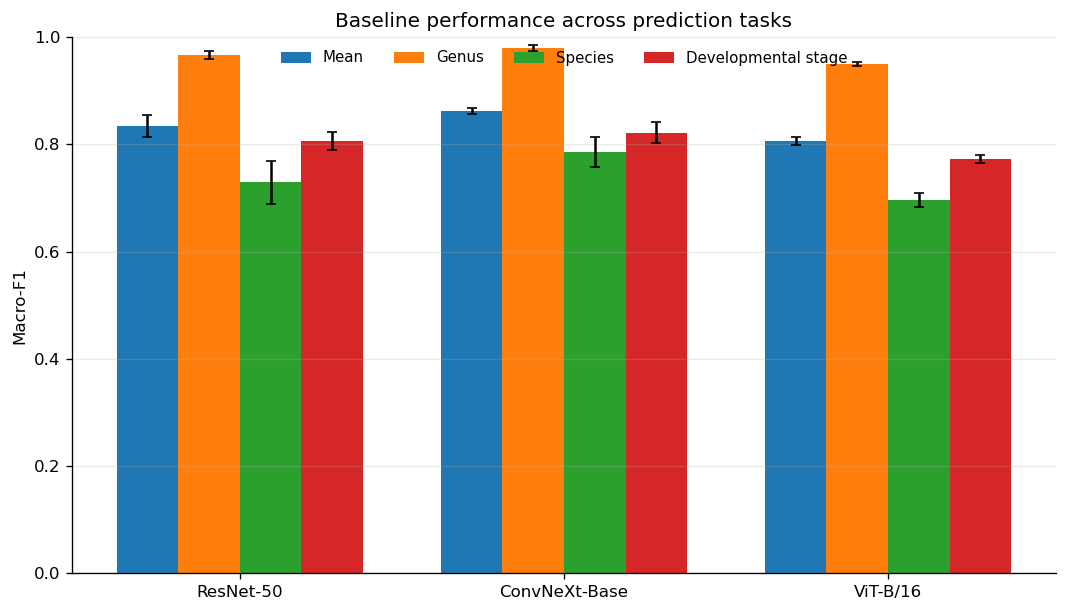

,Mean,Genus,Species,Developmental stage
Backbone,,,,
ResNet-50,0.834 $\pm$ 0.021,0.966 $\pm$ 0.007,0.729 $\pm$ 0.040,0.806 $\pm$ 0.017
ConvNeXt-Base,0.862 $\pm$ 0.006,0.980 $\pm$ 0.006,0.786 $\pm$ 0.027,0.821 $\pm$ 0.020
ViT-B/16,0.806 $\pm$ 0.007,0.950 $\pm$ 0.004,0.696 $\pm$ 0.013,0.772 $\pm$ 0.008


In [4]:
baseline = results[results["stage"].eq("baseline")].copy()
metrics = list(METRIC_COLUMNS)

mean_table = baseline.groupby("model")[metrics].mean().reindex(MODEL_ORDER)
sd_table = baseline.groupby("model")[metrics].std().reindex(MODEL_ORDER)

fig, ax = plt.subplots(figsize=(9.0, 5.2))
x = np.arange(len(MODEL_ORDER))
width = 0.19
for j, metric in enumerate(metrics):
    offset = (j - (len(metrics)-1)/2) * width
    ax.bar(
        x + offset,
        mean_table[metric],
        width=width,
        yerr=sd_table[metric],
        capsize=3,
        label=METRIC_COLUMNS[metric],
    )
ax.set_xticks(x, [MODEL_LABELS[m] for m in MODEL_ORDER])
ax.set_ylabel("Macro-F1")
ax.set_ylim(0, 1)
ax.set_title("Baseline performance across prediction tasks")
ax.grid(axis="y", alpha=0.25)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False, ncol=4)
fig.tight_layout()
save_figure(fig, "figure_01_combined_baseline")
plt.show()

# Manuscript LaTeX table: mean ± SD.
formatted = pd.DataFrame(index=[MODEL_LABELS[m] for m in MODEL_ORDER])
for metric, label in METRIC_COLUMNS.items():
    formatted[label] = [
        f"{mean_table.loc[m, metric]:.3f} $\\pm$ {sd_table.loc[m, metric]:.3f}"
        for m in MODEL_ORDER
    ]
formatted.index.name = "Backbone"
formatted.to_latex(
    TABLE_DIR / "table_01_baseline_performance.tex",
    escape=False,
    column_format="l" + "c" * len(formatted.columns),
    caption="Baseline macro-F1 across three random seeds. Values are mean $\\pm$ standard deviation.",
    label="tab:baseline-performance",
)
formatted

## Figure 2. Combined visual-ablation figure

All visual interventions are merged into one heatmap. Each cell is the change in task-specific macro-F1 relative to the matched original-image control (`resolution_loss_000pct`) for the same backbone and loss recipe.

Saved figure_02_combined_visual_ablation as SVG, PDF, and PNG


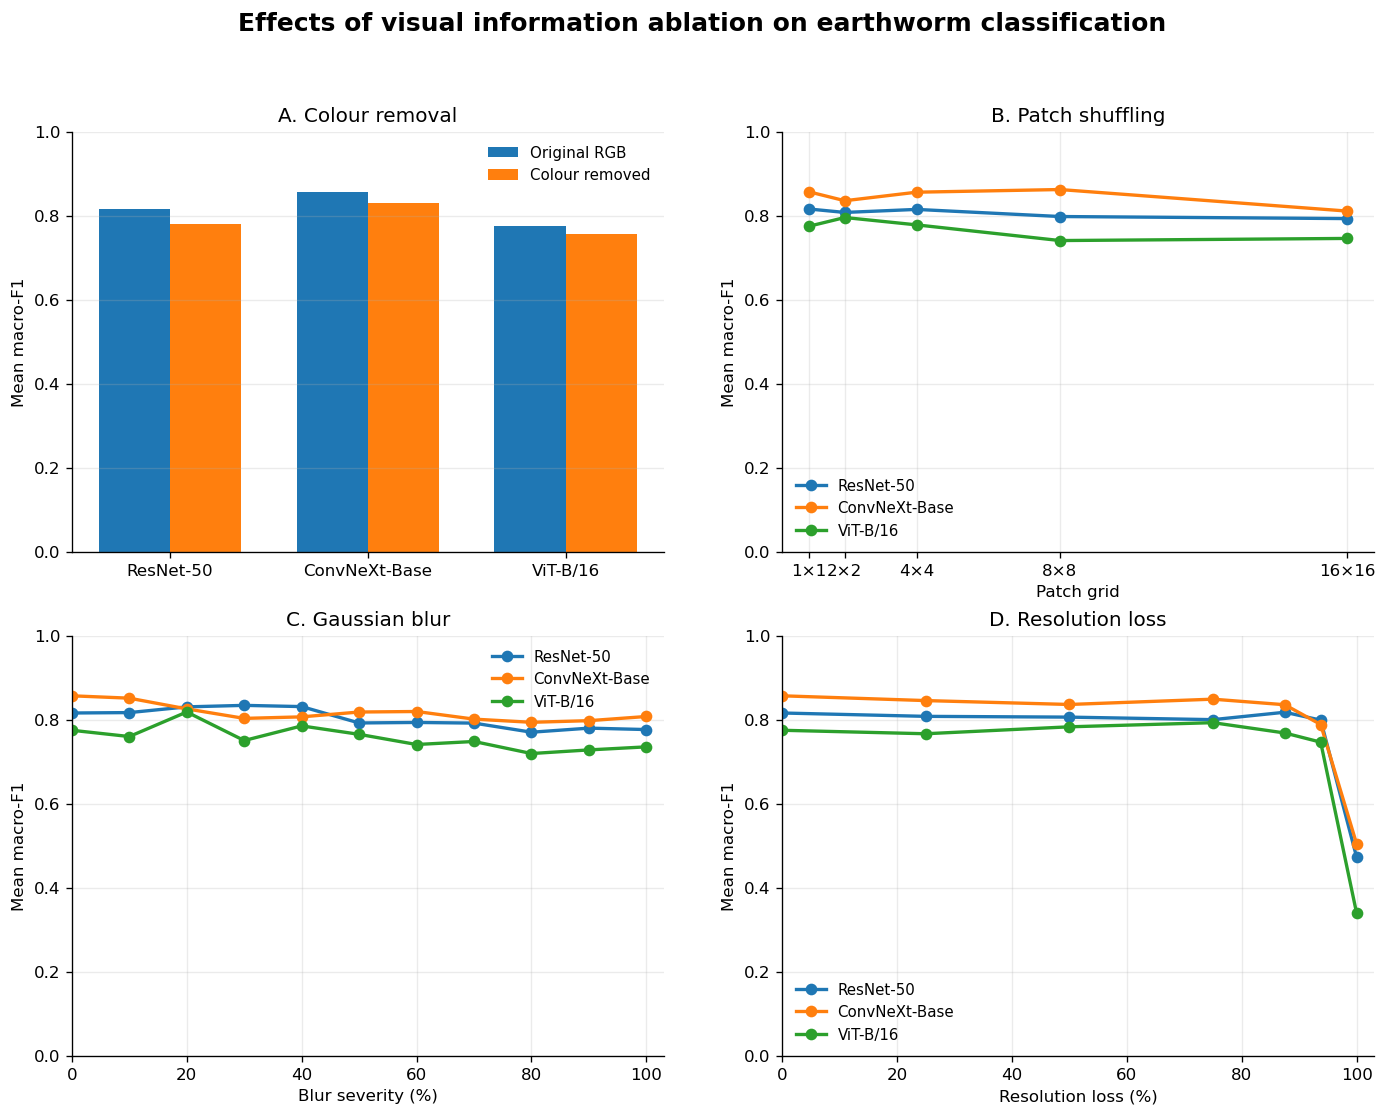

In [14]:
# ============================================================
# Combined visual-ablation figure: four subplots
# ============================================================

visual = results[results["stage"].eq("visual_ablation")].copy()

# Matched original-image control:
# same seed and loss recipe as the visual-ablation experiments.
matched_control = (
    visual[
        visual["transform"].eq("resolution_loss")
        & visual["percent"].eq(0)
    ]
    .set_index("model")
    .reindex(MODEL_ORDER)
)

if matched_control.index.has_duplicates:
    raise ValueError("Expected exactly one matched control per model.")

fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(14, 10),
  
  
)

ax_colour, ax_patch, ax_blur, ax_resolution = axes.flatten()


# ------------------------------------------------------------
# A. Colour removal
# ------------------------------------------------------------

colour = (
    visual[visual["transform"].eq("saturation")]
    .set_index("model")
    .reindex(MODEL_ORDER)
)

x = np.arange(len(MODEL_ORDER))
width = 0.36

ax_colour.bar(
    x - width / 2,
    matched_control["test_mean_macro_f1"],
    width=width,
    label="Original RGB",
)

ax_colour.bar(
    x + width / 2,
    colour["test_mean_macro_f1"],
    width=width,
    label="Colour removed",
)

ax_colour.set_xticks(
    x,
    [MODEL_LABELS[model] for model in MODEL_ORDER],
)

ax_colour.set_title("A. Colour removal")
ax_colour.set_ylabel("Mean macro-F1")
ax_colour.set_ylim(0, 1)
ax_colour.grid(axis="y", alpha=0.25)
ax_colour.legend(frameon=False)


# ------------------------------------------------------------
# B. Patch shuffling
# ------------------------------------------------------------

patch = visual[
    visual["transform"].eq("patch_shuffle")
].copy()

# Add the original image as a conceptual 1 × 1 grid.
patch_control = matched_control.reset_index().copy()
patch_control["grid_size"] = 1.0

patch_plot = pd.concat(
    [patch_control, patch],
    ignore_index=True,
)

for model in MODEL_ORDER:
    model_data = (
        patch_plot[patch_plot["model"].eq(model)]
        .sort_values("grid_size")
    )

    ax_patch.plot(
        model_data["grid_size"],
        model_data["test_mean_macro_f1"],
        marker="o",
        linewidth=2,
        label=MODEL_LABELS[model],
    )

grid_ticks = [1, 2, 4, 8, 16]

ax_patch.set_xticks(
    grid_ticks,
    [f"{grid}×{grid}" for grid in grid_ticks],
)

ax_patch.set_title("B. Patch shuffling")
ax_patch.set_xlabel("Patch grid")
ax_patch.set_ylabel("Mean macro-F1")
ax_patch.set_ylim(0, 1)
ax_patch.grid(alpha=0.25)
ax_patch.legend(frameon=False)


# ------------------------------------------------------------
# C. Gaussian blur
# ------------------------------------------------------------

blur = visual[
    visual["transform"].eq("gaussian_blur_percent")
].copy()

# Add the matched original-image control at 0% blur.
blur_control = matched_control.reset_index().copy()
blur_control["percent"] = 0.0

blur_plot = pd.concat(
    [blur_control, blur],
    ignore_index=True,
)

for model in MODEL_ORDER:
    model_data = (
        blur_plot[blur_plot["model"].eq(model)]
        .sort_values("percent")
    )

    ax_blur.plot(
        model_data["percent"],
        model_data["test_mean_macro_f1"],
        marker="o",
        linewidth=2,
        label=MODEL_LABELS[model],
    )

ax_blur.set_title("C. Gaussian blur")
ax_blur.set_xlabel("Blur severity (%)")
ax_blur.set_ylabel("Mean macro-F1")
ax_blur.set_ylim(0, 1)
ax_blur.set_xlim(0, 103)
ax_blur.grid(alpha=0.25)
ax_blur.legend(frameon=False)


# ------------------------------------------------------------
# D. Resolution loss
# ------------------------------------------------------------

resolution = (
    visual[visual["transform"].eq("resolution_loss")]
    .copy()
    .sort_values(["model", "percent"])
)

for model in MODEL_ORDER:
    model_data = resolution[
        resolution["model"].eq(model)
    ].sort_values("percent")

    ax_resolution.plot(
        model_data["percent"],
        model_data["test_mean_macro_f1"],
        marker="o",
        linewidth=2,
        label=MODEL_LABELS[model],
    )

ax_resolution.set_title("D. Resolution loss")
ax_resolution.set_xlabel("Resolution loss (%)")
ax_resolution.set_ylabel("Mean macro-F1")
ax_resolution.set_ylim(0, 1)
ax_resolution.set_xlim(0, 103)
ax_resolution.grid(alpha=0.25)
ax_resolution.legend(frameon=False)


# ------------------------------------------------------------
# Shared formatting
# ------------------------------------------------------------

for ax in axes.flatten():
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.suptitle(
    "Effects of visual information ablation on earthworm classification",
    fontsize=15,
    fontweight="bold",
)

save_figure(
    fig,
    "figure_02_combined_visual_ablation",
)

plt.show()

Saved figure_03_structured_holdout_subplots as SVG, PDF, and PNG


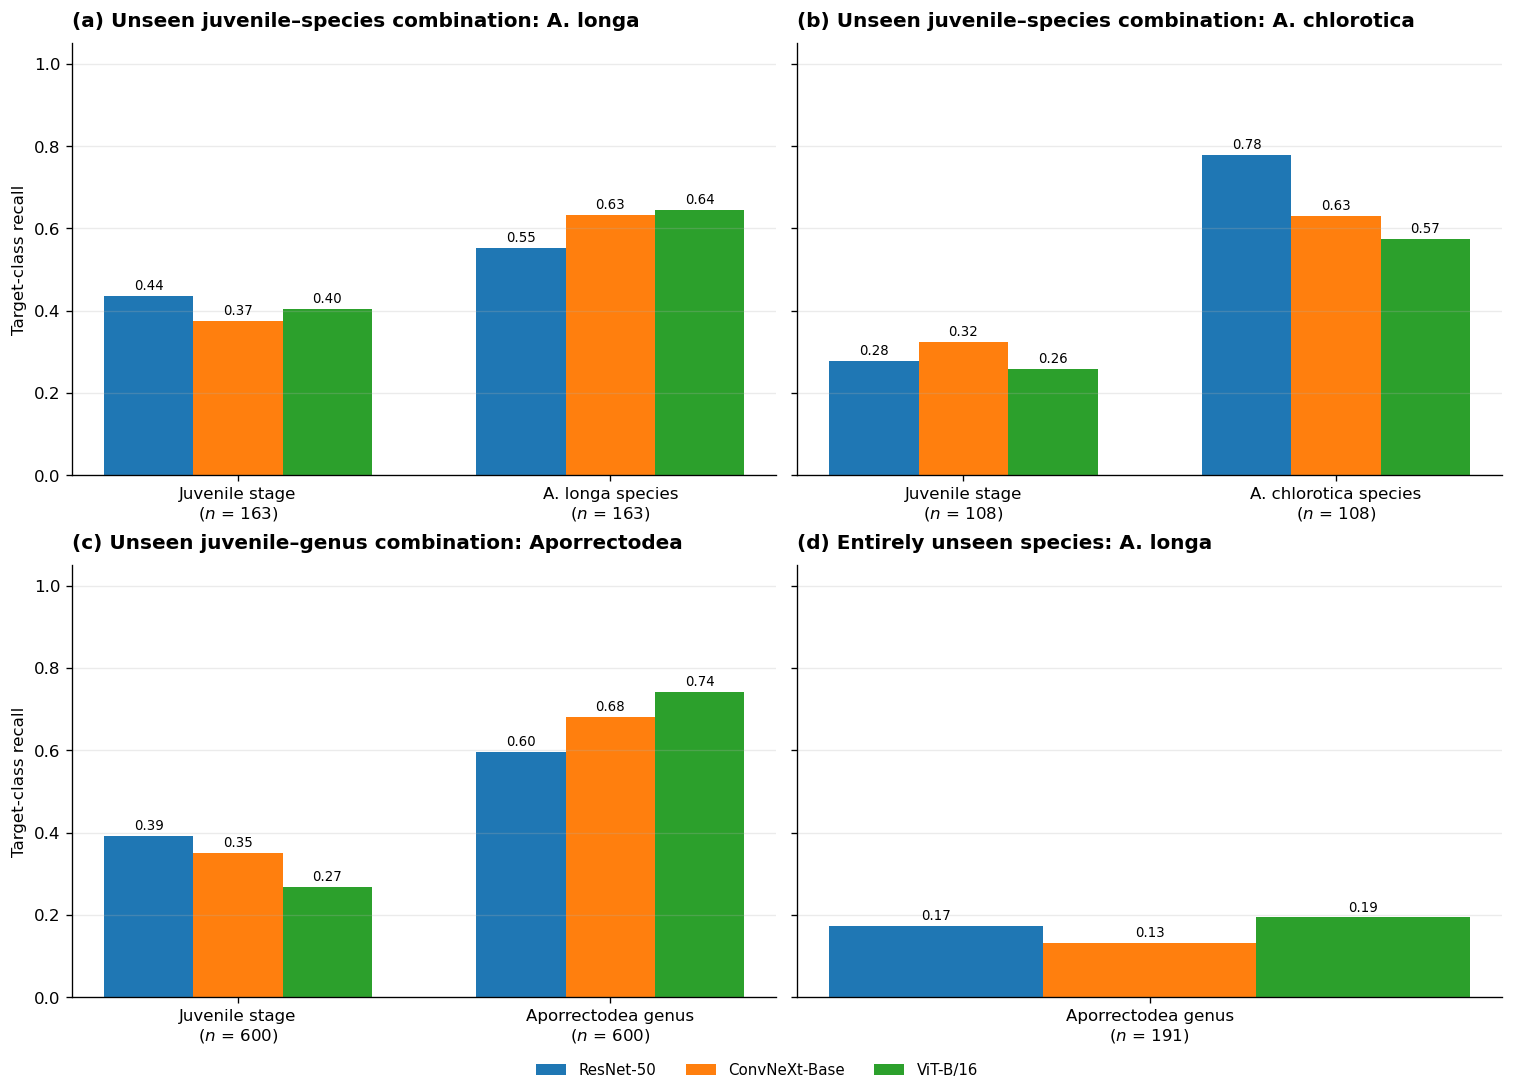

In [15]:
# ============================================================
# Figure 3: structured biological holdouts
# Descriptions and interpretations are placed in LaTeX.
# ============================================================

fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(12.5, 9.0),
    sharey=True,
    constrained_layout=True,
)

axes = axes.ravel()
bar_width = 0.24

for ax, holdout in zip(axes, HOLDOUT_ORDER):
    design = HOLDOUT_DESIGN[holdout]
    tasks = design["task_order"]
    x = np.arange(len(tasks), dtype=float)

    subset = holdout_targets[
        holdout_targets["holdout"].eq(holdout)
    ].copy()

    for model_index, model in enumerate(MODEL_ORDER):
        values = []

        for task in tasks:
            selected = subset[
                subset["model"].eq(model)
                & subset["task"].eq(task)
            ]

            value = (
                np.nan
                if selected.empty
                else selected.iloc[0]["target_recall"]
            )
            values.append(value)

        positions = x + (model_index - 1) * bar_width

        bars = ax.bar(
            positions,
            values,
            width=bar_width,
            label=MODEL_LABELS[model],
        )

        ax.bar_label(
            bars,
            fmt="%.2f",
            padding=2,
            fontsize=8,
        )

    # Sample size for each evaluated target.
    n_values = (
        subset.groupby("task", observed=True)["target_n"]
        .first()
        .to_dict()
    )

    tick_labels = [
        f'{design["task_labels"][task]}\n'
        f'($n$ = {int(n_values[task])})'
        for task in tasks
    ]

    ax.set_xticks(x, tick_labels)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Target-class recall")

    # Only a short panel identifier and name remain in the plot.
    ax.set_title(
        f'({design["letter"].lower()}) {design["short_title"]}',
        loc="left",
        fontweight="bold",
        pad=10,
    )

    ax.grid(axis="y", alpha=0.25)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


# Avoid repeated y-axis labels on the right-hand panels.
axes[1].set_ylabel("")
axes[3].set_ylabel("")

# One shared legend for the complete figure.
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="outside lower center",
    ncol=len(MODEL_ORDER),
    frameon=False,
)

save_figure(
    fig,
    "figure_03_structured_holdout_subplots",
)

plt.show()

Selected ConvNeXt run: /faststorage/project/worm-species/source/paper_result/runs/baseline/run_003_convnext_base_original_seed_40_20260729201916/lr_0.0003_hloss_False_8b056322_train_original
Seed: 40
Best validation score: 0.9128
Saved figure_04_convnext_normalised_confusion_matrices as SVG, PDF, and PNG


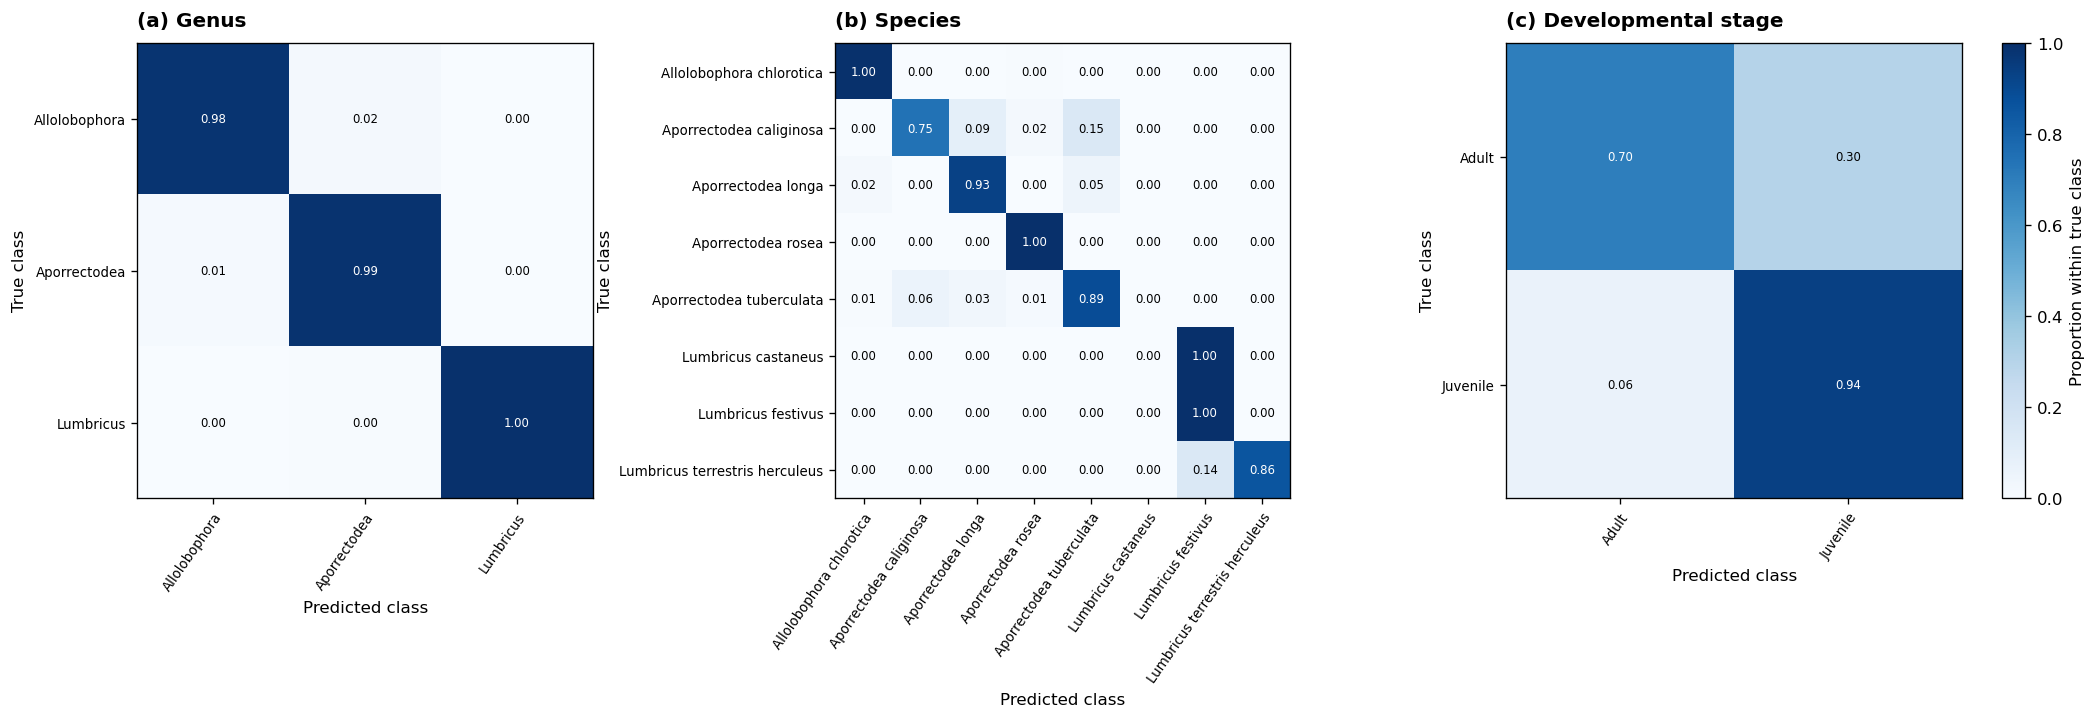

In [18]:
# ============================================================
# ConvNeXt-Base row-normalised confusion matrices
# Three prediction tasks in one figure
# ============================================================

CONVNEXT_MODEL = "convnext_base"

# Select the ConvNeXt baseline run with the highest
# validation-selection score.
convnext_candidates = results[
    results["stage"].eq("baseline")
    & results["model"].eq(CONVNEXT_MODEL)
].copy()

if convnext_candidates.empty:
    raise ValueError(
        "No ConvNeXt-Base baseline runs were found."
    )

convnext_best = convnext_candidates.loc[
    convnext_candidates["best_val_score"].idxmax()
]

convnext_run_dir = Path(convnext_best["run_dir"])

if not convnext_run_dir.exists():
    raise FileNotFoundError(
        f"ConvNeXt run directory is unavailable: "
        f"{convnext_run_dir}"
    )

print(
    "Selected ConvNeXt run:",
    convnext_run_dir,
)

print(
    "Seed:",
    int(convnext_best["seed"]),
)

print(
    "Best validation score:",
    f'{convnext_best["best_val_score"]:.4f}',
)


def display_class_label(label):
    """Make stored labels easier to read on figure axes."""
    return str(label).replace("_", " ")


# Load and normalise all three matrices first.
normalised_matrices = {}
matrix_labels = {}

for task in TASK_ORDER:
    matrix, row_labels, col_labels, source = (
        load_confusion_matrix(
            run_dir=convnext_run_dir,
            task=task,
            checkpoint=CHECKPOINT,
        )
    )

    row_sums = matrix.sum(
        axis=1,
        keepdims=True,
    )

    normalised = np.divide(
        matrix,
        row_sums,
        out=np.zeros_like(matrix, dtype=float),
        where=row_sums != 0,
    )

    normalised_matrices[task] = normalised
    matrix_labels[task] = {
        "rows": [display_class_label(x) for x in row_labels],
        "columns": [display_class_label(x) for x in col_labels],
        "source": source,
    }


# Scale the height according to the largest matrix.
largest_matrix = max(
    matrix.shape[0]
    for matrix in normalised_matrices.values()
)

figure_height = max(
    5.5,
    min(10.0, 0.36 * largest_matrix + 3.0),
)

fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(18, figure_height),
    constrained_layout=True,
)

panel_letters = {
    "genus": "a",
    "species": "b",
    "age": "c",
}

last_image = None

for ax, task in zip(axes, TASK_ORDER):
    normalised = normalised_matrices[task]
    labels = matrix_labels[task]

    last_image = ax.imshow(
        normalised,
        vmin=0,
        vmax=1,
        cmap="Blues",
        interpolation="nearest",
    )

    ax.set_xticks(
        np.arange(len(labels["columns"])),
        labels["columns"],
        rotation=55,
        ha="right",
        rotation_mode="anchor",
    )

    ax.set_yticks(
        np.arange(len(labels["rows"])),
        labels["rows"],
    )

    ax.set_xlabel("Predicted class")
    ax.set_ylabel("True class")

    ax.set_title(
        f'({panel_letters[task]}) {TASK_LABELS[task]}',
        loc="left",
        fontweight="bold",
        pad=10,
    )

    # Reduce tick-label size for larger taxonomic matrices.
    tick_fontsize = (
        7
        if max(normalised.shape) > 12
        else 8
    )

    ax.tick_params(
        axis="both",
        labelsize=tick_fontsize,
    )

    # Add cell values when the matrix is not too large.
    if max(normalised.shape) <= 15:
        for row_index in range(normalised.shape[0]):
            for column_index in range(normalised.shape[1]):
                value = normalised[
                    row_index,
                    column_index,
                ]

                ax.text(
                    column_index,
                    row_index,
                    f"{value:.2f}",
                    ha="center",
                    va="center",
                    fontsize=7,
                    color=(
                        "white"
                        if value >= 0.50
                        else "black"
                    ),
                )


# Use one colour scale for all three panels.
colourbar = fig.colorbar(
    last_image,
    ax=axes.tolist(),
    fraction=0.025,
    pad=0.02,
)

colourbar.set_label(
    "Proportion within true class"
)

save_figure(
    fig,
    "figure_04_convnext_normalised_confusion_matrices"
)

plt.show()

## Figure 3 and Table 3. Structured biological holdouts

The four panels correspond to four distinct biological generalisation questions.
Each panel states what was removed from training and validation, what biological
evidence remained available, and the target-class recall obtained on the withheld
test cohort. Target recall is used because it directly measures whether the
withheld juvenile stage, species, or genus was recognised.

The companion table reports the same results numerically and bolds the strongest
backbone for each biological target. All holdout results currently use one random
seed (`seed = 42`) and should therefore be interpreted descriptively.


Saved figure_03_structured_holdout_subplots as SVG, PDF, and PNG


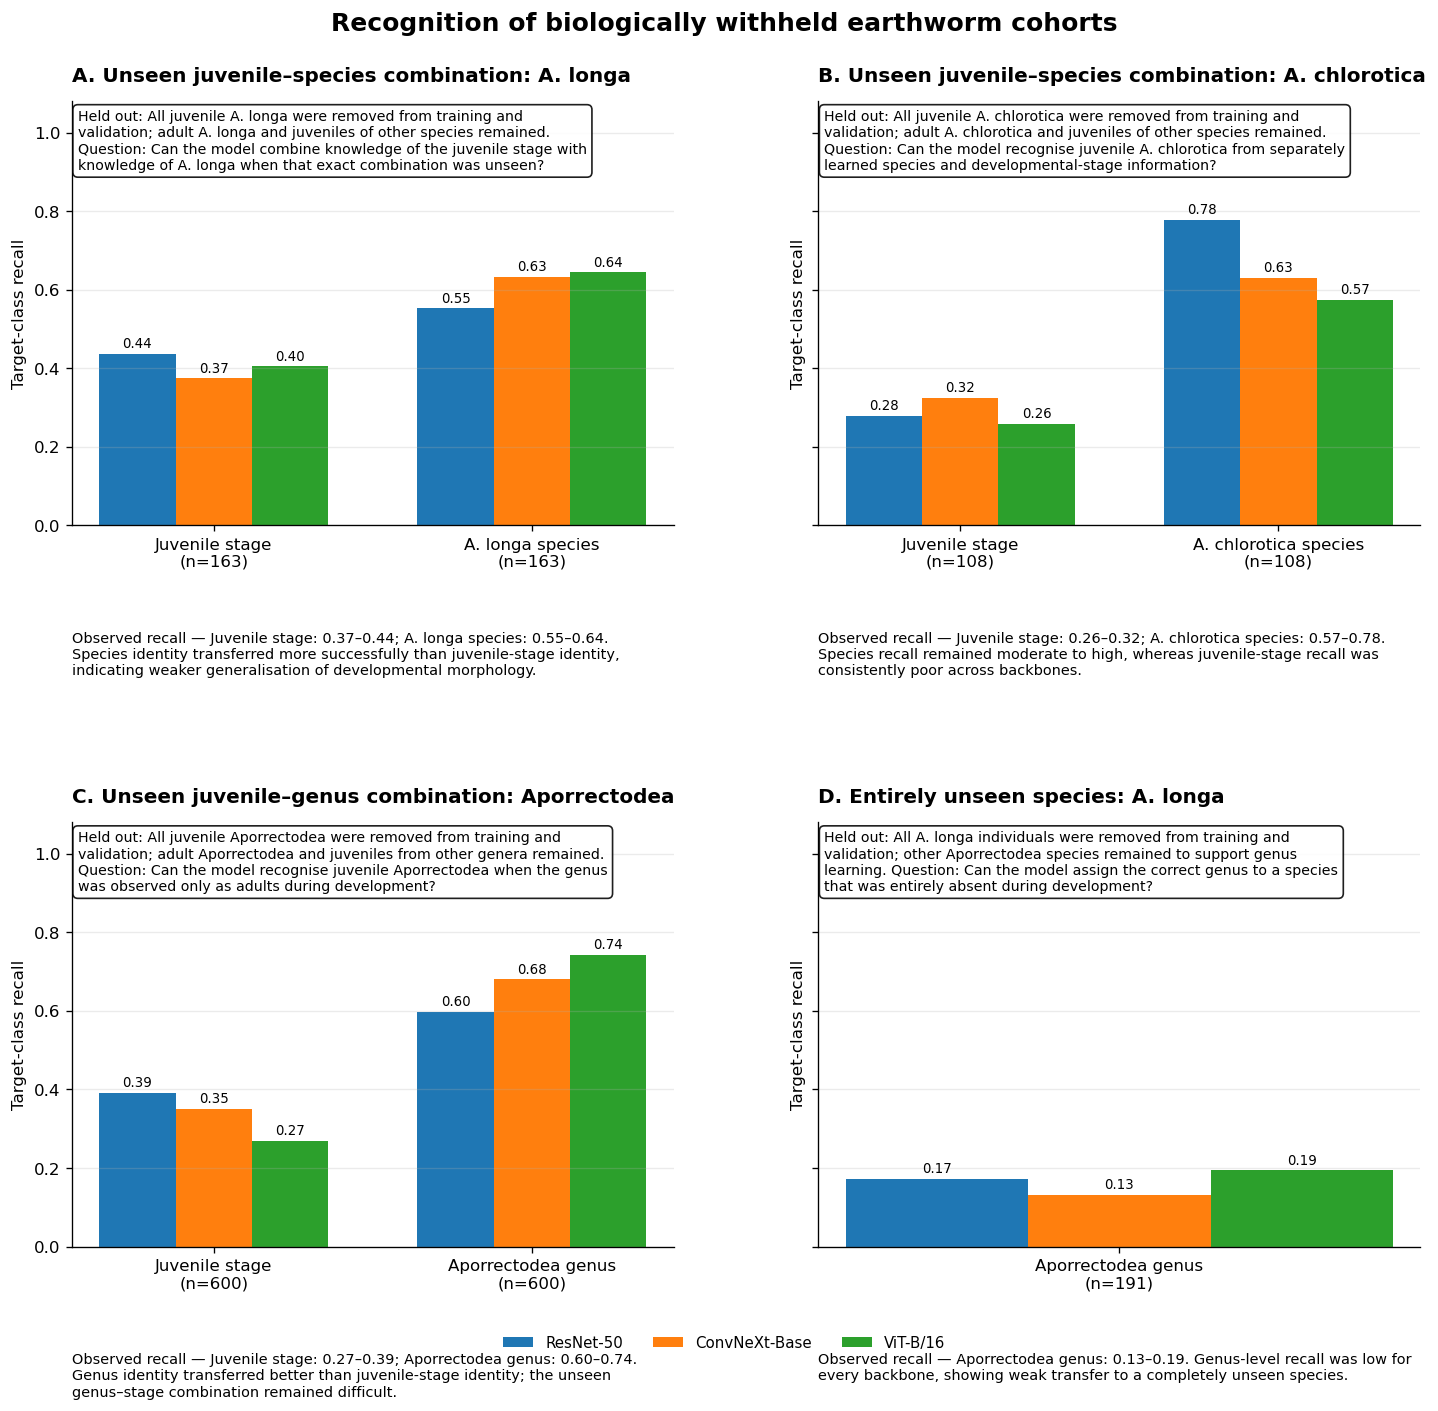

worm_species_manuscript_outputs/tables/table_03_structured_holdout_summary.tex


,Experiment,Holdout design,Target,n,resnet50,convnext_base,vit_b_16,Interpretation
0,A,All juvenile A. longa were removed from traini...,Juvenile stage,163,\textbf{0.436},0.374,0.405,Species identity transferred more successfully...
1,A,All juvenile A. longa were removed from traini...,A. longa species,163,0.552,0.632,\textbf{0.644},Species identity transferred more successfully...
2,B,All juvenile A. chlorotica were removed from t...,Juvenile stage,108,0.278,\textbf{0.324},0.259,"Species recall remained moderate to high, wher..."
3,B,All juvenile A. chlorotica were removed from t...,A. chlorotica species,108,\textbf{0.778},0.630,0.574,"Species recall remained moderate to high, wher..."
4,C,All juvenile Aporrectodea were removed from tr...,Juvenile stage,600,\textbf{0.392},0.350,0.268,Genus identity transferred better than juvenil...
5,C,All juvenile Aporrectodea were removed from tr...,Aporrectodea genus,600,0.597,0.680,\textbf{0.742},Genus identity transferred better than juvenil...
6,D,All A. longa individuals were removed from tra...,Aporrectodea genus,191,0.173,0.131,\textbf{0.194},"Genus-level recall was low for every backbone,..."


In [6]:
import textwrap

HOLDOUT_DESIGN = {
    "juvenile_aporrectodea_longa": {
        "letter": "A",
        "short_title": "Unseen juvenile–species combination: A. longa",
        "held_out": (
            "All juvenile A. longa were removed from training and validation; "
            "adult A. longa and juveniles of other species remained."
        ),
        "question": (
            "Can the model combine knowledge of the juvenile stage with knowledge "
            "of A. longa when that exact combination was unseen?"
        ),
        "task_order": ["age", "species"],
        "task_labels": {
            "age": "Juvenile stage",
            "species": "A. longa species",
        },
        "interpretation": (
            "Species identity transferred more successfully than juvenile-stage "
            "identity, indicating weaker generalisation of developmental morphology."
        ),
    },
    "juvenile_allolobophora_chlorotica": {
        "letter": "B",
        "short_title": "Unseen juvenile–species combination: A. chlorotica",
        "held_out": (
            "All juvenile A. chlorotica were removed from training and validation; "
            "adult A. chlorotica and juveniles of other species remained."
        ),
        "question": (
            "Can the model recognise juvenile A. chlorotica from separately learned "
            "species and developmental-stage information?"
        ),
        "task_order": ["age", "species"],
        "task_labels": {
            "age": "Juvenile stage",
            "species": "A. chlorotica species",
        },
        "interpretation": (
            "Species recall remained moderate to high, whereas juvenile-stage recall "
            "was consistently poor across backbones."
        ),
    },
    "juvenile_genus_aporrectodea": {
        "letter": "C",
        "short_title": "Unseen juvenile–genus combination: Aporrectodea",
        "held_out": (
            "All juvenile Aporrectodea were removed from training and validation; "
            "adult Aporrectodea and juveniles from other genera remained."
        ),
        "question": (
            "Can the model recognise juvenile Aporrectodea when the genus was observed "
            "only as adults during development?"
        ),
        "task_order": ["age", "genus"],
        "task_labels": {
            "age": "Juvenile stage",
            "genus": "Aporrectodea genus",
        },
        "interpretation": (
            "Genus identity transferred better than juvenile-stage identity; the "
            "unseen genus–stage combination remained difficult."
        ),
    },
    "unseen_species_aporrectodea_longa_for_genus": {
        "letter": "D",
        "short_title": "Entirely unseen species: A. longa",
        "held_out": (
            "All A. longa individuals were removed from training and validation; "
            "other Aporrectodea species remained to support genus learning."
        ),
        "question": (
            "Can the model assign the correct genus to a species that was entirely "
            "absent during development?"
        ),
        "task_order": ["genus"],
        "task_labels": {
            "genus": "Aporrectodea genus",
        },
        "interpretation": (
            "Genus-level recall was low for every backbone, showing weak transfer to "
            "a completely unseen species."
        ),
    },
}

HOLDOUT_ORDER = list(HOLDOUT_DESIGN)

# ---------------------------
# Figure 3: four-panel summary
# ---------------------------
fig, axes = plt.subplots(2, 2, figsize=(14.5, 11.5), sharey=True)
axes = axes.ravel()
bar_width = 0.24

for ax, holdout in zip(axes, HOLDOUT_ORDER):
    design = HOLDOUT_DESIGN[holdout]
    tasks = design["task_order"]
    x = np.arange(len(tasks), dtype=float)

    subset = holdout_targets[holdout_targets["holdout"].eq(holdout)].copy()

    for model_index, model in enumerate(MODEL_ORDER):
        values = []
        for task in tasks:
            selected = subset[
                subset["model"].eq(model)
                & subset["task"].eq(task)
            ]
            values.append(
                np.nan if selected.empty else selected.iloc[0]["target_recall"]
            )

        positions = x + (model_index - 1) * bar_width
        bars = ax.bar(
            positions,
            values,
            width=bar_width,
            label=MODEL_LABELS[model],
        )
        ax.bar_label(bars, fmt="%.2f", padding=2, fontsize=8)

    n_values = subset.groupby("task")["target_n"].first().to_dict()
    tick_labels = [
        f'{design["task_labels"][task]}\n(n={int(n_values[task])})'
        for task in tasks
    ]

    ax.set_xticks(x, tick_labels)
    ax.set_ylim(0, 1.08)
    ax.set_ylabel("Target-class recall")
    ax.grid(axis="y", alpha=0.25)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.set_title(
        f'{design["letter"]}. {design["short_title"]}',
        loc="left",
        fontweight="bold",
        pad=12,
    )

    explanatory_text = (
        f'Held out: {design["held_out"]}\n'
        f'Question: {design["question"]}'
    )
    ax.text(
        0.01,
        0.98,
        textwrap.fill(explanatory_text, width=72),
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=8.5,
        bbox={"boxstyle": "round,pad=0.35", "facecolor": "white", "alpha": 0.88},
    )

    task_ranges = []
    for task in tasks:
        task_values = subset.loc[subset["task"].eq(task), "target_recall"]
        task_ranges.append(
            f'{design["task_labels"][task]}: '
            f'{task_values.min():.2f}–{task_values.max():.2f}'
        )
    result_text = (
        "Observed recall — " + "; ".join(task_ranges) + ". "
        + design["interpretation"]
    )
    ax.text(
        0.0,
        -0.25,
        textwrap.fill(result_text, width=80),
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=8.7,
    )

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=len(MODEL_ORDER),
    frameon=False,
    bbox_to_anchor=(0.5, 0.015),
)
fig.suptitle(
    "Recognition of biologically withheld earthworm cohorts",
    fontsize=15,
    fontweight="bold",
    y=0.995,
)
fig.subplots_adjust(top=0.93, bottom=0.10, hspace=0.70, wspace=0.24)
save_figure(fig, "figure_03_structured_holdout_subplots")
plt.show()

# ----------------------------------------
# Table 3: experimental design and results
# ----------------------------------------
summary_rows = []
for holdout in HOLDOUT_ORDER:
    design = HOLDOUT_DESIGN[holdout]
    subset = holdout_targets[holdout_targets["holdout"].eq(holdout)].copy()

    for task in design["task_order"]:
        task_data = (
            subset[subset["task"].eq(task)]
            .set_index("model")
            .reindex(MODEL_ORDER)
        )
        values = task_data["target_recall"]
        best_value = values.max()

        formatted_values = {}
        for model, value in values.items():
            formatted = f"{value:.3f}"
            if np.isclose(value, best_value):
                formatted = rf"\textbf{{{formatted}}}"
            formatted_values[model] = formatted

        target_label = design["task_labels"][task]
        n_value = int(task_data["target_n"].dropna().iloc[0])

        summary_rows.append({
            "Experiment": design["letter"],
            "Holdout design": design["held_out"],
            "Target": target_label,
            "n": n_value,
            "resnet50": formatted_values["resnet50"],
            "convnext_base": formatted_values["convnext_base"],
            "vit_b_16": formatted_values["vit_b_16"],
            "Interpretation": design["interpretation"],
        })

holdout_summary = pd.DataFrame(summary_rows)
holdout_summary.to_csv(
    TABLE_DIR / "table_03_structured_holdout_summary.csv",
    index=False,
)

latex_lines = [
    r"\begin{table*}[t]",
    r"\caption{Target-class recall under structured biological holdouts. All listed cohorts were removed from training and validation but retained in the test set. The holdout-design column states which related biological evidence remained available during training. Bold values indicate the highest recall for each target. $n$ is the number of target test observations. All results are from seed 42.}",
    r"\label{tab:structured-holdouts}",
    r"\centering",
    r"\small",
    r"\setlength{\tabcolsep}{3pt}",
    r"\begin{tabular}{@{}clp{4.2cm}p{2.2cm}rcccp{4.1cm}@{}}",
    r"\toprule",
    r"Exp. & & Holdout design & Target & $n$ & ResNet-50 & ConvNeXt-Base & ViT-B/16 & Interpretation \\",
    r"\midrule",
]

previous_experiment = None
for _, row in holdout_summary.iterrows():
    experiment = row["Experiment"]
    exp_cell = experiment if experiment != previous_experiment else ""
    holdout_cell = latex_escape(row["Holdout design"]) if experiment != previous_experiment else ""
    interpretation_cell = latex_escape(row["Interpretation"]) if experiment != previous_experiment else ""

    target = row["Target"]
    target = target.replace("A. longa", r"\textit{A. longa}")
    target = target.replace("A. chlorotica", r"\textit{A. chlorotica}")
    target = target.replace("Aporrectodea", r"\textit{Aporrectodea}")

    latex_lines.append(
        f'{exp_cell} & & {holdout_cell} & {target} & {row["n"]} & '
        f'{row["resnet50"]} & {row["convnext_base"]} & {row["vit_b_16"]} & '
        f'{interpretation_cell} \\\\'
    )
    previous_experiment = experiment

latex_lines.extend([
    r"\bottomrule",
    r"\end{tabular}",
    r"\end{table*}",
])

holdout_tex_path = TABLE_DIR / "table_03_structured_holdout_summary.tex"
holdout_tex_path.write_text("\n".join(latex_lines), encoding="utf-8")
print(holdout_tex_path)

holdout_summary


In [ ]:
# ============================================================
# Test-selected ConvNeXt confusion matrices
# Genus, species, and age in one row-normalised figure
# ============================================================

CM_MODEL = "convnext_base"
CM_SELECTION_METRIC = "test_mean_macro_f1"
CM_STAGE = "baseline"
CM_CHECKPOINT = "best"


# ------------------------------------------------------------
# Select the ConvNeXt run using test mean macro-F1
# ------------------------------------------------------------

convnext_candidates = results[
    results["stage"].eq(CM_STAGE)
    & results["model"].eq(CM_MODEL)
].copy()

if convnext_candidates.empty:
    raise ValueError(
        f"No runs found for model={CM_MODEL!r} "
        f"and stage={CM_STAGE!r}."
    )

if CM_SELECTION_METRIC not in convnext_candidates.columns:
    raise KeyError(
        f"Missing selection metric: {CM_SELECTION_METRIC}"
    )

convnext_candidates = convnext_candidates.dropna(
    subset=[CM_SELECTION_METRIC]
)

selected_run = convnext_candidates.loc[
    convnext_candidates[CM_SELECTION_METRIC].idxmax()
]

selected_run_dir = Path(selected_run["run_dir"])

print("Selected model:", MODEL_LABELS.get(CM_MODEL, CM_MODEL))
print("Selected seed:", int(selected_run["seed"]))
print(
    "Test mean macro-F1:",
    f"{selected_run[CM_SELECTION_METRIC]:.4f}",
)
print("Run directory:", selected_run_dir)


if not selected_run_dir.exists():
    raise FileNotFoundError(
        f"Run directory is unavailable:\n{selected_run_dir}\n\n"
        "Run this cell on the Genome cluster."
    )


# ------------------------------------------------------------
# Load and row-normalise the three saved test matrices
# ------------------------------------------------------------

normalised_matrices = {}
matrix_labels = {}
matrix_sources = {}

for task in TASK_ORDER:
    matrix, row_labels, column_labels, source_path = (
        load_confusion_matrix(
            run_dir=selected_run_dir,
            task=task,
            checkpoint=CM_CHECKPOINT,
        )
    )

    row_sums = matrix.sum(
        axis=1,
        keepdims=True,
    )

    normalised_matrix = np.divide(
        matrix,
        row_sums,
        out=np.zeros_like(matrix, dtype=float),
        where=row_sums != 0,
    )

    normalised_matrices[task] = normalised_matrix

    matrix_labels[task] = {
        "rows": [
            str(label).replace("_", " ")
            for label in row_labels
        ],
        "columns": [
            str(label).replace("_", " ")
            for label in column_labels
        ],
    }

    matrix_sources[task] = str(source_path)

    print(
        f"{task}: loaded {source_path.name}, "
        f"shape={matrix.shape}"
    )


# ------------------------------------------------------------
# Create one figure containing all three confusion matrices
# ------------------------------------------------------------

panel_letters = {
    "genus": "a",
    "species": "b",
    "age": "c",
}

largest_dimension = max(
    max(matrix.shape)
    for matrix in normalised_matrices.values()
)

figure_height = max(
    5.8,
    min(11.0, 0.35 * largest_dimension + 3.2),
)

fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(19, figure_height),
    constrained_layout=True,
)

last_image = None

for ax, task in zip(axes, TASK_ORDER):
    matrix = normalised_matrices[task]
    labels = matrix_labels[task]

    last_image = ax.imshow(
        matrix,
        cmap="Blues",
        vmin=0,
        vmax=1,
        interpolation="nearest",
        aspect="equal",
    )

    ax.set_xticks(
        np.arange(len(labels["columns"])),
        labels["columns"],
        rotation=55,
        ha="right",
        rotation_mode="anchor",
    )

    ax.set_yticks(
        np.arange(len(labels["rows"])),
        labels["rows"],
    )

    ax.set_xlabel("Predicted class")
    ax.set_ylabel("True class")

    ax.set_title(
        f"({panel_letters[task]}) {TASK_LABELS[task]}",
        loc="left",
        fontweight="bold",
        pad=10,
    )

    if max(matrix.shape) > 15:
        tick_fontsize = 6
    elif max(matrix.shape) > 10:
        tick_fontsize = 7
    else:
        tick_fontsize = 8

    ax.tick_params(
        axis="both",
        labelsize=tick_fontsize,
    )

    # Add values only when the matrix remains readable.
    if max(matrix.shape) <= 15:
        for row_index in range(matrix.shape[0]):
            for column_index in range(matrix.shape[1]):
                value = matrix[
                    row_index,
                    column_index,
                ]

                ax.text(
                    column_index,
                    row_index,
                    f"{value:.2f}",
                    ha="center",
                    va="center",
                    fontsize=7,
                    color=(
                        "white"
                        if value >= 0.50
                        else "black"
                    ),
                )


# One shared colour scale for the three panels.
colourbar = fig.colorbar(
    last_image,
    ax=list(axes),
    fraction=0.025,
    pad=0.02,
)

colourbar.set_label(
    "Proportion within true class"
)


# ------------------------------------------------------------
# Export figure
# ------------------------------------------------------------

figure_stem = (
    "figure_04_convnext_test_selected_"
    "normalised_confusion_matrices"
)

save_figure(
    fig,
    figure_stem,
    CM_DIR,
)

plt.show()


# ------------------------------------------------------------
# Record exactly which run and files generated the figure
# ------------------------------------------------------------

selection_record = pd.DataFrame([
    {
        "model": selected_run["model"],
        "seed": int(selected_run["seed"]),
        "selection_stage": CM_STAGE,
        "selection_split": "test",
        "selection_metric": CM_SELECTION_METRIC,
        "selection_value": selected_run[
            CM_SELECTION_METRIC
        ],
        "run_dir": str(selected_run_dir),
        "genus_confusion_matrix": matrix_sources["genus"],
        "species_confusion_matrix": matrix_sources["species"],
        "age_confusion_matrix": matrix_sources["age"],
    }
])

selection_record.to_csv(
    OUTPUT_DIR
    / "convnext_test_selected_confusion_matrix_run.csv",
    index=False,
)

selection_record

Selected model: ConvNeXt-Base
Selected seed: 42
Test mean macro-F1: 0.8687
Run directory: /faststorage/project/worm-species/source/paper_result/runs/baseline/run_005_convnext_base_original_seed_42_20260729201916/lr_0.0003_hloss_False_4f21266e_train_original
genus: loaded confusion_matrix_best_genus.csv, shape=(3, 3)
species: loaded confusion_matrix_best_species.csv, shape=(8, 8)
age: loaded confusion_matrix_best_age.csv, shape=(2, 2)


## Confusion matrices from saved run artefacts

The code below reads the existing matrices directly. It exports one raw-count and one row-normalised figure per selected run and task; it does not attempt to reconstruct matrices from summary metrics.

In [7]:
def plot_saved_confusion_matrix(run_dir, task, descriptor, checkpoint=CHECKPOINT):
    matrix, row_labels, col_labels, source = load_confusion_matrix(run_dir, task, checkpoint)
    stem_base = safe_stem(f"{descriptor}_{task}")

    # Raw counts.
    fig, ax = plt.subplots(figsize=(max(6, 0.42*len(col_labels)+3), max(5, 0.42*len(row_labels)+2)))
    image = ax.imshow(matrix, cmap="Blues")
    ax.set_xticks(np.arange(len(col_labels)), col_labels, rotation=55, ha="right")
    ax.set_yticks(np.arange(len(row_labels)), row_labels)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_title(f"{descriptor}: {TASK_LABELS[task]} confusion matrix")
    if len(row_labels) <= 15:
        threshold = matrix.max()/2 if matrix.size else 0
        for i in range(matrix.shape[0]):
            for j in range(matrix.shape[1]):
                ax.text(j, i, f"{matrix[i,j]:.0f}", ha="center", va="center", color="white" if matrix[i,j] > threshold else "black", fontsize=8)
    fig.colorbar(image, ax=ax, label="Count")
    fig.tight_layout()
    save_figure(fig, f"{stem_base}_raw", CM_DIR)
    plt.close(fig)

    # Row-normalised recall view.
    row_sums = matrix.sum(axis=1, keepdims=True)
    normalised = np.divide(matrix, row_sums, out=np.zeros_like(matrix, dtype=float), where=row_sums != 0)
    fig, ax = plt.subplots(figsize=(max(6, 0.42*len(col_labels)+3), max(5, 0.42*len(row_labels)+2)))
    image = ax.imshow(normalised, cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks(np.arange(len(col_labels)), col_labels, rotation=55, ha="right")
    ax.set_yticks(np.arange(len(row_labels)), row_labels)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_title(f"{descriptor}: row-normalised {TASK_LABELS[task]} confusion matrix")
    if len(row_labels) <= 15:
        for i in range(normalised.shape[0]):
            for j in range(normalised.shape[1]):
                ax.text(j, i, f"{normalised[i,j]:.2f}", ha="center", va="center", color="white" if normalised[i,j] > 0.5 else "black", fontsize=8)
    fig.colorbar(image, ax=ax, label="Proportion within true class")
    fig.tight_layout()
    save_figure(fig, f"{stem_base}_normalised", CM_DIR)
    plt.close(fig)
    return source


def build_cm_plan():
    plan=[]
    if GENERATE_BASELINE_CMS:
        best_baseline = (
            results[results["stage"].eq("baseline")]
            .sort_values("best_val_score")
            .groupby("model", as_index=False)
            .tail(1)
        )
        for _, row in best_baseline.iterrows():
            for task in TASK_ORDER:
                plan.append({
                    "run_dir": row["run_dir"], "task": task,
                    "descriptor": f"baseline_{row['model']}_seed_{row['seed']}",
                })

    if GENERATE_HOLDOUT_CMS:
        for _, row in holdout_targets.drop_duplicates(["run_dir", "task"]).iterrows():
            plan.append({
                "run_dir": row["run_dir"], "task": row["task"],
                "descriptor": f"holdout_{row['model']}_{row['holdout']}",
            })

    if GENERATE_VISUAL_CMS:
        selected = results[
            results["stage"].eq("visual_ablation")
            & results["model"].isin(VISUAL_CM_MODELS)
            & results["condition"].isin(VISUAL_CM_CONDITIONS)
        ]
        for _, row in selected.iterrows():
            for task in TASK_ORDER:
                plan.append({
                    "run_dir": row["run_dir"], "task": task,
                    "descriptor": f"visual_{row['model']}_{row['condition']}",
                })
    return pd.DataFrame(plan).drop_duplicates()

cm_plan = build_cm_plan()
print(f"Planned confusion matrices: {len(cm_plan)}")

cm_log=[]
for _, item in cm_plan.iterrows():
    if not Path(item["run_dir"]).exists():
        cm_log.append({**item.to_dict(), "status": "run_dir unavailable", "source": ""})
        continue
    try:
        source = plot_saved_confusion_matrix(item["run_dir"], item["task"], item["descriptor"])
        cm_log.append({**item.to_dict(), "status": "created", "source": str(source)})
    except Exception as error:
        cm_log.append({**item.to_dict(), "status": f"error: {error}", "source": ""})

cm_log = pd.DataFrame(cm_log)
cm_log.to_csv(OUTPUT_DIR / "confusion_matrix_log.csv", index=False)
cm_log["status"].value_counts(dropna=False)

Planned confusion matrices: 30
Saved baseline_vit_b_16_seed_41_genus_raw as SVG, PDF, and PNG
Saved baseline_vit_b_16_seed_41_genus_normalised as SVG, PDF, and PNG
Saved baseline_vit_b_16_seed_41_species_raw as SVG, PDF, and PNG
Saved baseline_vit_b_16_seed_41_species_normalised as SVG, PDF, and PNG
Saved baseline_vit_b_16_seed_41_age_raw as SVG, PDF, and PNG
Saved baseline_vit_b_16_seed_41_age_normalised as SVG, PDF, and PNG
Saved baseline_resnet50_seed_42_genus_raw as SVG, PDF, and PNG
Saved baseline_resnet50_seed_42_genus_normalised as SVG, PDF, and PNG
Saved baseline_resnet50_seed_42_species_raw as SVG, PDF, and PNG
Saved baseline_resnet50_seed_42_species_normalised as SVG, PDF, and PNG
Saved baseline_resnet50_seed_42_age_raw as SVG, PDF, and PNG
Saved baseline_resnet50_seed_42_age_normalised as SVG, PDF, and PNG
Saved baseline_convnext_base_seed_40_genus_raw as SVG, PDF, and PNG
Saved baseline_convnext_base_seed_40_genus_normalised as SVG, PDF, and PNG
Saved baseline_convnext_base

status
created    30
Name: count, dtype: int64

## Classification-report LaTeX tables

For every confusion-matrix plan entry, the matching best-checkpoint classification report is exported as a separate LaTeX table. Summary rows such as accuracy and macro average are retained.

In [8]:
report_log=[]
for _, item in cm_plan.iterrows():
    run_dir = Path(item["run_dir"])
    if not run_dir.exists():
        report_log.append({**item.to_dict(), "status": "run_dir unavailable"})
        continue
    try:
        report, source = load_classification_report(run_dir, item["task"])
        output_name = safe_stem(f"classification_report_{item['descriptor']}_{item['task']}") + ".tex"
        output_path = REPORT_DIR / output_name
        caption = f"Classification report for {item['descriptor']} ({TASK_LABELS[item['task']]} task)."
        report.to_latex(
            output_path,
            float_format="%.3f",
            longtable=len(report) > 20,
            caption=latex_escape(caption),
            label=f"tab:{safe_stem(item['descriptor']).lower()}-{item['task']}",
        )
        report_log.append({**item.to_dict(), "status": "created", "source": str(source), "latex": str(output_path)})
    except Exception as error:
        report_log.append({**item.to_dict(), "status": f"error: {error}"})

report_log = pd.DataFrame(report_log)
report_log.to_csv(OUTPUT_DIR / "classification_report_log.csv", index=False)
report_log["status"].value_counts(dropna=False)

status
created    30
Name: count, dtype: int64

## LaTeX inclusion snippets

This cell writes a small file that can be copied into the Springer Nature manuscript. Confusion-matrix paths are listed in the logs because their exact number depends on the selected plan.

In [9]:
snippets = r"""
% Required packages already present in the Springer Nature template:
% \usepackage{graphicx}
% \usepackage{booktabs}

\begin{figure}[t]
  \centering
  \includegraphics[width=\linewidth]{worm_species_manuscript_outputs/figures/figure_01_combined_baseline.pdf}
  \caption{Baseline macro-F1 for genus, species, developmental-stage, and mean multi-task performance. Bars show means across three random seeds and error bars show one standard deviation.}
  \label{fig:baseline-performance}
\end{figure}

\begin{figure*}[t]
  \centering
  \includegraphics[width=\textwidth]{worm_species_manuscript_outputs/figures/figure_02_combined_visual_ablation.pdf}
  \caption{Changes in task-specific macro-F1 under matched visual-ablation conditions relative to the original-image control. Training, validation, and test images received the same transformation within each run.}
  \label{fig:visual-ablation}
\end{figure*}

\begin{figure*}[t]
  \centering
  \includegraphics[width=\textwidth]{worm_species_manuscript_outputs/figures/figure_03_structured_holdout_subplots.pdf}
  \caption{Target-class recall for four structured biological holdouts. (A) Juvenile \textit{Aporrectodea longa} was absent from training and validation, while adult \textit{A. longa} and juveniles of other species remained. Species recall exceeded juvenile-stage recall, indicating better transfer of species identity than developmental morphology. (B) Juvenile \textit{Allolobophora chlorotica} was withheld under the same design. Species recall remained moderate to high, whereas juvenile-stage recall was low. (C) All juvenile \textit{Aporrectodea} were withheld, while adult members of the genus and juveniles of other genera remained. Genus recall exceeded juvenile-stage recall. (D) All \textit{A. longa} individuals were withheld, while other \textit{Aporrectodea} species remained. Low genus recall indicated weak transfer to a completely unseen species. Bars show target-class recall for one random seed (seed 42); values are therefore descriptive rather than estimates of optimisation uncertainty.}
  \label{fig:structured-holdouts}
\end{figure*}

\input{worm_species_manuscript_outputs/tables/table_01_baseline_performance.tex}
\input{worm_species_manuscript_outputs/tables/table_03_structured_holdout_summary.tex}
"""
(OUTPUT_DIR / "latex_includes.tex").write_text(snippets, encoding="utf-8")
print(OUTPUT_DIR / "latex_includes.tex")


worm_species_manuscript_outputs/latex_includes.tex


In [6]:
from __future__ import annotations

from pathlib import Path
import re

import numpy as np
import pandas as pd


# ============================================================
# Paths
# ============================================================

TABLE_DIR = Path.cwd()

# Allow the script to run from the repository root.
if not (
    TABLE_DIR / "dataset_composition_by_taxon_stage_and_split.csv"
).exists():
    TABLE_DIR = Path("tables")

if not TABLE_DIR.exists():
    raise FileNotFoundError(f"Table directory not found: {TABLE_DIR}")

LATEX_DIR = TABLE_DIR / "latex"
MAIN_DIR = LATEX_DIR / "main"
SUPPLEMENT_DIR = LATEX_DIR / "supplementary"

for directory in (LATEX_DIR, MAIN_DIR, SUPPLEMENT_DIR):
    directory.mkdir(parents=True, exist_ok=True)


# ============================================================
# General utilities
# ============================================================

def canonical_name(value: str) -> str:
    """Convert a column name to lower-case snake case."""
    value = re.sub(r"[^A-Za-z0-9]+", "_", str(value))
    return value.strip("_").lower()


def load_csv(filename: str) -> pd.DataFrame:
    """Read a CSV and standardise its column names."""
    path = TABLE_DIR / filename

    if not path.exists():
        raise FileNotFoundError(f"Missing required file: {path}")

    frame = pd.read_csv(path)
    frame.columns = [canonical_name(column) for column in frame.columns]
    return frame


def find_column(
    frame: pd.DataFrame,
    candidates: list[str],
) -> str | None:
    """Return the first candidate column present in a data frame."""
    canonical_candidates = [
        canonical_name(candidate)
        for candidate in candidates
    ]

    for candidate in canonical_candidates:
        if candidate in frame.columns:
            return candidate

    return None


def existing_columns(
    frame: pd.DataFrame,
    candidates: list[str],
) -> list[str]:
    """Return candidate columns that are present."""
    result = []

    for candidate in candidates:
        candidate = canonical_name(candidate)

        if candidate in frame.columns and candidate not in result:
            result.append(candidate)

    return result


COLUMN_LABELS = {
    "genus": "Genus",
    "species": "Species",
    "developmental_stage": "Stage",
    "stage": "Stage",
    "age": "Stage",
    "split": "Split",
    "train": "Train",
    "training": "Train",
    "validation": "Validation",
    "val": "Validation",
    "test": "Test",
    "total": "Total",
    "model": "Backbone",
    "seed": "Seed",
    "task": "Task",
    "condition": "Condition",
    "transform": "Transformation",
    "holdout": "Holdout",
    "holdout_question": "Question",
    "question": "Question",
    "target_label": "Target class",
    "target_n": "Target $n$",
    "target_recall": "Target recall",
    "n_individuals": "Individuals",
    "individuals": "Individuals",
    "individual_count": "Individuals",
    "n_images": "Images",
    "image_count": "Images",
    "removed_train_individuals": "Removed train",
    "removed_validation_individuals": "Removed validation",
    "removed_val_individuals": "Removed validation",
    "test_individuals": "Test",
    "heldout_test_individuals": "Test",
    "class_supported_by_training_head": "Class retained",
    "mean_macro_f1": "Macro-F1",
    "test_mean_macro_f1": "Mean macro-F1",
    "test_genus_macro_f1": "Genus macro-F1",
    "test_species_macro_f1": "Species macro-F1",
    "test_age_macro_f1": "Stage macro-F1",
    "macro_f1": "Macro-F1",
    "accuracy": "Accuracy",
    "balanced_accuracy": "Balanced accuracy",
    "best_val_score": "Best validation score",
    "best_epoch": "Best epoch",
    "n_seeds": "Seeds",
    "total_parameters": "Parameters",
    "trainable_parameters": "Trainable parameters",
    "pretrained": "Pretrained",
    "learning_rate": "Learning rate",
    "batch_size": "Batch size",
    "loss_recipe": "Loss recipe",
    "genus_weight": "Genus weight",
    "species_weight": "Species weight",
    "age_weight": "Stage weight",
    "percent": "Severity (\\%)",
    "grid_size": "Grid size",
    "colour_retention": "Colour retained",
}


def display_column(column: str) -> str:
    """Return a readable LaTeX column heading."""
    return COLUMN_LABELS.get(
        column,
        column.replace("_", " ").capitalize(),
    )


def clean_values(frame: pd.DataFrame) -> pd.DataFrame:
    """Format common categorical values for display."""
    frame = frame.copy()

    for column in frame.select_dtypes(include="object").columns:
        frame[column] = (
            frame[column]
            .astype(str)
            .replace({"nan": np.nan})
        )

    for column in frame.columns:
        if column in {
            "species",
            "genus",
            "target_label",
            "holdout",
            "condition",
            "transform",
        }:
            frame[column] = (
                frame[column]
                .astype(str)
                .str.replace("_", " ", regex=False)
                .replace({"nan": np.nan})
            )

    for column in frame.columns:
        if frame[column].dtype == bool:
            frame[column] = frame[column].map({
                True: "Yes",
                False: "No",
            })

    return frame


from pathlib import Path
import re

import numpy as np
import pandas as pd


def latex_escape_text(value) -> str:
    """Escape ordinary text for use in LaTeX."""
    if pd.isna(value):
        return "--"

    text = str(value)

    replacements = {
        "\\": r"\textbackslash{}",
        "&": r"\&",
        "%": r"\%",
        "$": r"\$",
        "#": r"\#",
        "_": r"\_",
        "{": r"\{",
        "}": r"\}",
        "~": r"\textasciitilde{}",
        "^": r"\textasciicircum{}",
    }

    for old, new in replacements.items():
        text = text.replace(old, new)

    return text


def format_taxon(value) -> str:
    """Format a genus or binomial species name in italics."""
    if pd.isna(value):
        return "--"

    name = str(value).replace("_", " ")
    return rf"\textit{{{latex_escape_text(name)}}}"


def prepare_latex_values(
    frame: pd.DataFrame,
    taxon_columns=("genus", "species"),
) -> pd.DataFrame:
    """Prepare text values while preserving LaTeX formatting."""
    output = frame.copy()

    for column in output.columns:
        if column in taxon_columns:
            output[column] = output[column].map(format_taxon)

        elif pd.api.types.is_bool_dtype(output[column]):
            output[column] = output[column].map({
                True: "Yes",
                False: "No",
            })

        elif pd.api.types.is_object_dtype(output[column]):
            output[column] = output[column].map(latex_escape_text)

    return output


def write_springer_table(
    frame: pd.DataFrame,
    *,
    filename: str,
    caption: str,
    label: str,
    column_format: str,
    directory: Path,
    column_labels: dict[str, str] | None = None,
    note: str | None = None,
    wide: bool = True,
    font_size: str = "scriptsize",
    float_digits: int = 3,
) -> Path:
    """
    Write a Springer Nature-compatible LaTeX table.

    Parameters
    ----------
    wide
        Use ``table*`` and ``tabular*`` for a two-column-width table.
    column_format
        For example:
        ``@{\\extracolsep{\\fill}}lllrrrr@{}``
    """
    directory.mkdir(parents=True, exist_ok=True)

    output = prepare_latex_values(frame)

    if column_labels:
        output = output.rename(columns=column_labels)

    tabular = output.to_latex(
        index=False,
        escape=False,
        na_rep="--",
        column_format=column_format,
        float_format=lambda value: f"{value:.{float_digits}f}",
    )

    # Springer examples use \botrule rather than \bottomrule.
    tabular = tabular.replace(r"\bottomrule", r"\botrule")

    if wide:
        tabular = tabular.replace(
            r"\begin{tabular}",
            r"\begin{tabular*}{\textwidth}",
            1,
        )
        tabular = tabular.replace(
            r"\end{tabular}",
            r"\end{tabular*}",
            1,
        )

    environment = "table*" if wide else "table"
    note_width = r"\textwidth" if wide else r"\linewidth"

    note_block = ""

    if note:
        note_block = (
            "\n"
            rf"\begin{{minipage}}{{{note_width}}}" "\n"
            r"\footnotesize\textit{Note:} "
            + note
            + "\n"
            r"\end{minipage}"
            + "\n"
        )

    latex = (
        rf"\begin{{{environment}}}[t]" "\n"
        rf"\caption{{{caption}}}"
        rf"\label{{{label}}}%" "\n"
        r"\centering" "\n"
        rf"\{font_size}" "\n"
        r"\setlength{\tabcolsep}{4pt}" "\n"
        r"\renewcommand{\arraystretch}{1.12}" "\n"
        + tabular
        + note_block
        + rf"\end{{{environment}}}" "\n"
    )

    output_path = directory / filename
    output_path.write_text(latex, encoding="utf-8")

    print(f"Written: {output_path}")
    return output_path


# ============================================================
# Table 1: baseline dataset split by individuals
# ============================================================
# ============================================================
# Table 1: baseline dataset split by individuals
# ============================================================

dataset = load_csv(
    "dataset_composition_by_taxon_stage_and_split.csv"
)

required_columns = [
    "genus",
    "species",
    "stage",
    "training_individuals",
    "validation_individuals",
    "test_individuals",
]

missing_columns = [
    column
    for column in required_columns
    if column not in dataset.columns
]

if missing_columns:
    raise ValueError(
        "Missing required dataset columns: "
        f"{missing_columns}"
    )

baseline_split = dataset[
    required_columns
].copy()

baseline_split = baseline_split.rename(
    columns={
        "training_individuals": "train",
        "validation_individuals": "validation",
        "test_individuals": "test",
    }
)

count_columns = [
    "train",
    "validation",
    "test",
]

baseline_split[count_columns] = (
    baseline_split[count_columns]
    .fillna(0)
    .astype(int)
)

baseline_split["total"] = baseline_split[
    count_columns
].sum(axis=1)

# Order the table consistently.
baseline_split = baseline_split.sort_values(
    ["genus", "species", "stage"]
).reset_index(drop=True)

write_latex_table(
    baseline_split,
    filename="table_01_baseline_dataset_split.tex",
    caption=(
        "Individual-level dataset composition by genus, species, "
        "developmental stage, and predefined data split."
    ),
    label="tab:baseline-dataset-split",
    directory=MAIN_DIR,
    wide=True,
    note=(
        "Counts represent individual earthworms rather than images. "
        "All images belonging to a given individual were assigned to "
        "one data split only."
    ),
)

# ============================================================
# Table 2: baseline performance with confidence intervals
# ============================================================
# Table 1: baseline dataset composition
# ============================================================

dataset = load_csv(
    "dataset_composition_by_taxon_stage_and_split.csv"
)

required_columns = [
    "genus",
    "species",
    "stage",
    "training_individuals",
    "validation_individuals",
    "test_individuals",
]

missing_columns = [
    column
    for column in required_columns
    if column not in dataset.columns
]

if missing_columns:
    raise ValueError(
        f"Missing required columns: {missing_columns}"
    )

baseline_split = dataset[required_columns].copy()

baseline_split = baseline_split.rename(
    columns={
        "training_individuals": "training",
        "validation_individuals": "validation",
        "test_individuals": "test",
    }
)

count_columns = [
    "training",
    "validation",
    "test",
]

baseline_split[count_columns] = (
    baseline_split[count_columns]
    .fillna(0)
    .astype(int)
)

baseline_split["total"] = baseline_split[
    count_columns
].sum(axis=1)

baseline_split = baseline_split.sort_values(
    ["genus", "species", "stage"]
).reset_index(drop=True)

write_springer_table(
    baseline_split,
    filename="table_01_baseline_dataset_split.tex",
    caption=(
        "Individual-level dataset composition by genus, species, "
        "developmental stage, and predefined data split."
    ),
    label="tab:baseline-dataset-split",
    directory=MAIN_DIR,
    wide=True,
    font_size="scriptsize",
    column_format=(
        r"@{\extracolsep{\fill}}"
        r"ll"
        r"l"
        r"rrrr"
        r"@{}"
    ),
    column_labels={
        "genus": "Genus",
        "species": "Species",
        "stage": "Developmental stage",
        "training": "Training",
        "validation": "Validation",
        "test": "Test",
        "total": "Total",
    },
    note=(
        "Counts represent biological individuals rather than images. "
        "All images belonging to a given individual were assigned to "
        "one split only."
    ),
)


# ============================================================
# Table 3: data-ablation definitions and individual counts
# ============================================================
# ============================================================
# Table 3: structured data-ablation design
# ============================================================
# ============================================================
# Table 3: structured data-ablation design
# ============================================================

holdouts = load_csv(
    "holdout_definitions_and_sample_counts.csv"
)


def first_available(
    frame: pd.DataFrame,
    candidates: list[str],
) -> str | None:
    """Return the first available column name."""
    return next(
        (
            candidate
            for candidate in candidates
            if candidate in frame.columns
        ),
        None,
    )


holdout_col = first_available(
    holdouts,
    [
        "holdout",
        "holdout_name",
        "held_out_cohort",
    ],
)

question_col = first_available(
    holdouts,
    [
        "question",
        "holdout_question",
        "research_question",
    ],
)

where_col = first_available(
    holdouts,
    [
        "where",
        "removal_location",
    ],
)

removed_training_individuals_col = first_available(
    holdouts,
    [
        "removed_training_individuals",
        "removed_train_individuals",
        "training_individuals_removed",
    ],
)

removed_validation_individuals_col = first_available(
    holdouts,
    [
        "removed_validation_individuals",
        "removed_val_individuals",
        "validation_individuals_removed",
    ],
)

test_individuals_col = first_available(
    holdouts,
    [
        "test_cohort_individuals",
        "test_individuals",
        "heldout_test_individuals",
        "target_test_individuals",
    ],
)

removed_training_images_col = first_available(
    holdouts,
    [
        "removed_training_images",
        "removed_train_images",
    ],
)

removed_validation_images_col = first_available(
    holdouts,
    [
        "removed_validation_images",
        "removed_val_images",
    ],
)

test_images_col = first_available(
    holdouts,
    [
        "test_cohort_images",
        "test_images",
        "heldout_test_images",
    ],
)


required_mapping = {
    "holdout": holdout_col,
    "removed_training_individuals": (
        removed_training_individuals_col
    ),
    "removed_validation_individuals": (
        removed_validation_individuals_col
    ),
    "test_cohort_individuals": test_individuals_col,
    "question": question_col,
}

missing = [
    output_name
    for output_name, source_name in required_mapping.items()
    if source_name is None
]

if missing:
    raise ValueError(
        f"Could not identify columns for: {missing}\n"
        f"Available columns: {holdouts.columns.tolist()}"
    )


# Include image counts when available.
optional_mapping = {
    "removed_training_images": removed_training_images_col,
    "removed_validation_images": removed_validation_images_col,
    "test_cohort_images": test_images_col,
    "where": where_col,
}

column_mapping = {
    **required_mapping,
    **{
        output_name: source_name
        for output_name, source_name in optional_mapping.items()
        if source_name is not None
    },
}

data_ablation_table = holdouts[
    list(column_mapping.values())
].copy()

data_ablation_table.columns = list(
    column_mapping.keys()
)


# Convert count columns to integers.
count_columns = [
    column
    for column in [
        "removed_training_individuals",
        "removed_training_images",
        "removed_validation_individuals",
        "removed_validation_images",
        "test_cohort_individuals",
        "test_cohort_images",
    ]
    if column in data_ablation_table.columns
]

data_ablation_table[count_columns] = (
    data_ablation_table[count_columns]
    .fillna(0)
    .astype(int)
)


# Make holdout names readable.
data_ablation_table["holdout"] = (
    data_ablation_table["holdout"]
    .astype(str)
    .str.replace("_", " ", regex=False)
)


# Recommended compact main-text version:
main_columns = [
    "holdout",
    "removed_training_individuals",
    "removed_validation_individuals",
    "test_cohort_individuals",
    "question",
]

data_ablation_main = data_ablation_table[
    main_columns
].copy()


write_springer_table(
    data_ablation_main,
    filename="table_03_data_ablation_individual_counts.tex",
    caption=(
        "Structured training-cohort ablations and the corresponding "
        "numbers of biological individuals."
    ),
    label="tab:data-ablation-counts",
    directory=MAIN_DIR,
    wide=True,
    font_size="scriptsize",
    column_format=(
        r"@{\extracolsep{\fill}}"
        r"p{0.21\textwidth}"
        r"rrr"
        r"p{0.39\textwidth}"
        r"@{}"
    ),
    column_labels={
        "holdout": "Withheld cohort",
        "removed_training_individuals": (
            "Removed from training"
        ),
        "removed_validation_individuals": (
            "Removed from validation"
        ),
        "test_cohort_individuals": (
            "Held-out test cohort"
        ),
        "question": "Generalisation question",
    },
    note=(
        "The indicated cohorts were excluded from training and "
        "validation, whereas their observations were retained in the "
        "predefined test set. Counts refer to biological individuals."
    ),
)

# ============================================================
# Table 4: target-specific holdout performance
# ============================================================

holdout_metrics = load_csv(
    "data_holdout_task_metrics.csv"
)

holdout_metric_columns = existing_columns(
    holdout_metrics,
    [
        "model",
        "seed",
        "holdout",
        "task",
        "target_label",
        "class_supported_by_training_head",
        "target_n",
        "target_recall",
        "macro_f1",
    ],
)

if not holdout_metric_columns:
    target_metric_table = holdout_metrics.copy()
else:
    target_metric_table = holdout_metrics[
        holdout_metric_columns
    ].copy()

write_latex_table(
    target_metric_table,
    filename="table_04_data_ablation_target_metrics.tex",
    caption=(
        "Target-class performance for the biologically structured "
        "training-cohort holdouts."
    ),
    label="tab:data-ablation-target-metrics",
    directory=MAIN_DIR,
    wide=True,
    note=(
        "Target recall is the primary measure because each restricted "
        "evaluation subset contains observations from one true target "
        "class for the stated task. Results currently represent seed 42."
    ),
)


# ============================================================
# Optional main or supplementary model-configuration table
# ============================================================

configurations = load_csv(
    "model_and_training_configurations.csv"
)

configuration_columns = existing_columns(
    configurations,
    [
        "model",
        "total_parameters",
        "trainable_parameters",
        "pretrained",
        "learning_rate",
        "batch_size",
        "selection_metric",
        "loss_recipe",
        "genus_weight",
        "species_weight",
        "age_weight",
    ],
)

configuration_table = (
    configurations[configuration_columns].copy()
    if configuration_columns
    else configurations.copy()
)

configuration_table = configuration_table.drop_duplicates()

write_latex_table(
    configuration_table,
    filename="table_s01_model_training_configurations.tex",
    caption=(
        "Model architectures and training configurations used in the "
        "baseline and ablation experiments."
    ),
    label="tab:model-configurations",
    directory=SUPPLEMENT_DIR,
    wide=True,
)


# ============================================================
# Supplementary result tables
# ============================================================

SUPPLEMENTARY_SPECS = [
    {
        "source": "baseline_metrics.csv",
        "output": "table_s02_baseline_seed_metrics.tex",
        "caption": (
            "Seed-level baseline test metrics for all model backbones."
        ),
        "label": "tab:supp-baseline-seeds",
        "columns": [
            "model",
            "seed",
            "best_epoch",
            "best_val_score",
            "test_mean_macro_f1",
            "test_genus_macro_f1",
            "test_species_macro_f1",
            "test_age_macro_f1",
        ],
    },
    {
        "source": "full_test_and_heldout_cohort_metrics.csv",
        "output": "table_s03_full_and_holdout_metrics.tex",
        "caption": (
            "Full-test and held-out-cohort performance for the "
            "structured data-ablation experiments."
        ),
        "label": "tab:supp-full-holdout",
        "columns": [
            "model",
            "seed",
            "holdout",
            "task",
            "n",
            "accuracy",
            "balanced_accuracy",
            "macro_f1",
            "target_n",
            "target_recall",
        ],
    },
    {
        "source": "experimental_ablation_definitions.csv",
        "output": "table_s04_ablation_definitions.tex",
        "caption": (
            "Definitions and interpretation of the visual and "
            "training-cohort ablations."
        ),
        "label": "tab:supp-ablation-definitions",
        "columns": [],
    },
    {
        "source": "visual_ablation_metrics.csv",
        "output": "table_s05_visual_ablation_metrics.tex",
        "caption": (
            "Complete test metrics for all matched visual-ablation "
            "conditions."
        ),
        "label": "tab:supp-visual-ablation",
        "columns": [
            "model",
            "seed",
            "condition",
            "transform",
            "percent",
            "grid_size",
            "colour_retention",
            "test_mean_macro_f1",
            "test_genus_macro_f1",
            "test_species_macro_f1",
            "test_age_macro_f1",
        ],
    },
    {
        "source": "resolution_loss_schedule.csv",
        "output": "table_s06_resolution_loss_schedule.tex",
        "caption": (
            "Resolution-loss schedule and corresponding intermediate "
            "image dimensions."
        ),
        "label": "tab:supp-resolution-schedule",
        "columns": [],
    },
    {
        "source": "matched_vs_original_test_metrics.csv",
        "output": "table_s07_matched_vs_original.tex",
        "caption": (
            "Comparison of matched-condition and original-image test "
            "performance."
        ),
        "label": "tab:supp-matched-original",
        "columns": [],
    },
    {
        "source": "visual_original_image_metrics.csv",
        "output": "table_s08_visual_original_metrics.tex",
        "caption": (
            "Performance of the visual-ablation models evaluated on "
            "original images."
        ),
        "label": "tab:supp-visual-original",
        "columns": [],
    },
    {
        "source": (
            "visual_trained_ablation_tested_on_original_metrics.csv"
        ),
        "output": "table_s09_ablation_to_original_transfer.tex",
        "caption": (
            "Transfer performance from visually ablated training data "
            "to original test images."
        ),
        "label": "tab:supp-ablation-original-transfer",
        "columns": [],
    },
]

generated_tables = []

for specification in SUPPLEMENTARY_SPECS:
    source_path = TABLE_DIR / specification["source"]

    if not source_path.exists():
        print(f"Skipped missing file: {source_path}")
        continue

    frame = load_csv(specification["source"])

    selected_columns = existing_columns(
        frame,
        specification["columns"],
    )

    if selected_columns:
        frame = frame[selected_columns].copy()

    output_path = write_latex_table(
        frame,
        filename=specification["output"],
        caption=specification["caption"],
        label=specification["label"],
        directory=SUPPLEMENT_DIR,
        wide=True,
    )

    generated_tables.append(output_path)


# ============================================================
# Compact run inventory
# ============================================================

all_runs_path = TABLE_DIR / "all_completed_runs.csv"

if all_runs_path.exists():
    all_runs = load_csv("all_completed_runs.csv")

    inventory_columns = existing_columns(
        all_runs,
        [
            "stage",
            "model",
            "seed",
            "condition",
            "holdout",
            "best_epoch",
            "best_val_score",
            "test_mean_macro_f1",
        ],
    )

    run_inventory = (
        all_runs[inventory_columns].copy()
        if inventory_columns
        else all_runs.copy()
    )

    write_latex_table(
        run_inventory,
        filename="table_s10_completed_run_inventory.tex",
        caption=(
            "Inventory of completed baseline, visual-ablation, and "
            "training-cohort-ablation runs."
        ),
        label="tab:supp-run-inventory",
        directory=SUPPLEMENT_DIR,
        wide=True,
        font_size="tiny",
    )


# ============================================================
# LaTeX inclusion file
# ============================================================

include_lines = [
    "% Main manuscript tables",
    r"\input{tables/latex/main/table_01_baseline_dataset_split.tex}",
    r"\input{tables/latex/main/table_02_baseline_performance.tex}",
    r"\input{tables/latex/main/table_03_data_ablation_individual_counts.tex}",
    r"\input{tables/latex/main/table_04_data_ablation_target_metrics.tex}",
    "",
    "% Supplementary tables",
    r"\input{tables/latex/supplementary/table_s01_model_training_configurations.tex}",
    r"\input{tables/latex/supplementary/table_s02_baseline_seed_metrics.tex}",
    r"\input{tables/latex/supplementary/table_s03_full_and_holdout_metrics.tex}",
    r"\input{tables/latex/supplementary/table_s04_ablation_definitions.tex}",
    r"\input{tables/latex/supplementary/table_s05_visual_ablation_metrics.tex}",
    r"\input{tables/latex/supplementary/table_s06_resolution_loss_schedule.tex}",
    r"\input{tables/latex/supplementary/table_s07_matched_vs_original.tex}",
    r"\input{tables/latex/supplementary/table_s08_visual_original_metrics.tex}",
    r"\input{tables/latex/supplementary/table_s09_ablation_to_original_transfer.tex}",
    r"\input{tables/latex/supplementary/table_s10_completed_run_inventory.tex}",
]

include_path = LATEX_DIR / "table_includes.tex"
include_path.write_text(
    "\n".join(include_lines) + "\n",
    encoding="utf-8",
)

print(f"\nLaTeX inclusion file written to: {include_path}")
supplementary_columns = [
    "holdout",
    "removed_training_individuals",
    "removed_training_images",
    "removed_validation_individuals",
    "removed_validation_images",
    "test_cohort_individuals",
    "test_cohort_images",
]

supplementary_columns = [
    column
    for column in supplementary_columns
    if column in data_ablation_table.columns
]

write_springer_table(
    data_ablation_table[supplementary_columns],
    filename="table_s_data_ablation_images_and_individuals.tex",
    caption=(
        "Numbers of individuals and images associated with each "
        "structured training-cohort ablation."
    ),
    label="tab:supp-data-ablation-counts",
    directory=SUPPLEMENT_DIR,
    wide=True,
    font_size="scriptsize",
    column_format=(
        r"@{\extracolsep{\fill}}"
        r"p{0.24\textwidth}"
        + "r" * (len(supplementary_columns) - 1)
        + r"@{}"
    ),
    column_labels={
        "holdout": "Withheld cohort",
        "removed_training_individuals": "Training individuals",
        "removed_training_images": "Training images",
        "removed_validation_individuals": "Validation individuals",
        "removed_validation_images": "Validation images",
        "test_cohort_individuals": "Test individuals",
        "test_cohort_images": "Test images",
    },
    note=(
        "Image counts exceed individual counts because multiple images "
        "were acquired for some earthworms. Dataset splitting and "
        "cohort removal were performed at the individual level."
    ),
)

/tmp/ipykernel_2646733/3114092057.py:161: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for column in frame.select_dtypes(include="object").columns:
/tmp/ipykernel_2646733/3114092057.py:161: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-se

Written: tables/latex/main/table_01_baseline_dataset_split.tex
Written: tables/latex/main/table_01_baseline_dataset_split.tex
Written: tables/latex/main/table_03_data_ablation_individual_counts.tex
Written: tables/latex/main/table_04_data_ablation_target_metrics.tex
Written: tables/latex/supplementary/table_s01_model_training_configurations.tex
Written: tables/latex/supplementary/table_s02_baseline_seed_metrics.tex
Written: tables/latex/supplementary/table_s03_full_and_holdout_metrics.tex
Written: tables/latex/supplementary/table_s04_ablation_definitions.tex
Written: tables/latex/supplementary/table_s05_visual_ablation_metrics.tex
Written: tables/latex/supplementary/table_s06_resolution_loss_schedule.tex
Written: tables/latex/supplementary/table_s07_matched_vs_original.tex


/tmp/ipykernel_2646733/3114092057.py:161: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for column in frame.select_dtypes(include="object").columns:
/tmp/ipykernel_2646733/3114092057.py:161: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-se

Written: tables/latex/supplementary/table_s08_visual_original_metrics.tex
Written: tables/latex/supplementary/table_s09_ablation_to_original_transfer.tex
Written: tables/latex/supplementary/table_s10_completed_run_inventory.tex

LaTeX inclusion file written to: tables/latex/table_includes.tex
Written: tables/latex/supplementary/table_s_data_ablation_images_and_individuals.tex


/tmp/ipykernel_2646733/3114092057.py:161: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for column in frame.select_dtypes(include="object").columns:
/tmp/ipykernel_2646733/3114092057.py:161: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-se

PosixPath('tables/latex/supplementary/table_s_data_ablation_images_and_individuals.tex')

## Recommended use in the paper

- Use the combined baseline, visual-ablation, and target-recall figures in the main manuscript.
- Use only the most biologically informative confusion matrices in the main text, such as the completely unseen-species genus matrix.
- Place the remaining confusion matrices and per-class classification reports in supplementary material.
- Because visual and holdout experiments currently have one seed, avoid inferential claims from small differences among backbones.